# QUESTION 1

In [1]:
# Imports and load the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read and display the dataset
df_q1 = pd.read_csv("question1/Cereals_Rating.csv")

df_q1.head()

,name,mfr,type,calories,protein (g),fat(g),sodium (mg),fiber (g),carbo (g),sugars (g),potass (mg),vitamins (%),shelf (Cff),weight (oz),cups,rating
0,Cap'n'Crunch,Q,C,120,1,2,220,0.0,12.0,12,35,25,2,1.0,0.75,18.042851
1,Cinnamon Toast Crunch,G,C,120,1,3,210,0.0,13.0,9,45,25,2,1.0,0.75,19.823573
2,Honey Graham Ohs,Q,C,120,1,2,220,1.0,12.0,11,45,25,2,1.0,1.00,21.871292
3,Count Chocula,G,C,110,1,1,180,0.0,12.0,13,65,25,2,1.0,1.00,22.396513
4,Cocoa Puffs,G,C,110,1,1,180,0.0,12.0,13,55,25,2,1.0,1.00,22.736446


## Initial EDA

In [3]:
# View features informations
df_q1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          76 non-null     object 
 1   mfr           76 non-null     object 
 2   type          76 non-null     object 
 3   calories      76 non-null     int64  
 4   protein (g)   76 non-null     int64  
 5   fat(g)        76 non-null     int64  
 6   sodium (mg)   76 non-null     int64  
 7   fiber (g)     76 non-null     float64
 8   carbo (g)     76 non-null     float64
 9   sugars (g)    76 non-null     int64  
 10  potass (mg)   76 non-null     int64  
 11  vitamins (%)  76 non-null     int64  
 12  shelf (Cff)   76 non-null     int64  
 13  weight (oz)   76 non-null     float64
 14  cups          76 non-null     float64
 15  rating        76 non-null     float64
dtypes: float64(5), int64(8), object(3)
memory usage: 9.6+ KB


In [4]:
# Statistical summary before cleaning/duplicate values
df_q1.describe().round(2)

,calories,protein (g),fat(g),sodium (mg),fiber (g),carbo (g),sugars (g),potass (mg),vitamins (%),shelf (Cff),weight (oz),cups,rating
count,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00
mean,106.97,2.51,1.00,161.78,2.14,14.80,7.03,101.64,28.62,2.22,1.03,0.82,42.56
std,19.60,1.06,1.01,82.32,2.40,3.91,4.38,72.70,22.25,0.83,0.15,0.23,14.11
min,50.00,1.00,0.00,0.00,0.00,5.00,0.00,15.00,0.00,1.00,0.50,0.25,18.04
25%,100.00,2.00,0.00,133.75,0.75,12.00,3.00,43.75,25.00,1.75,1.00,0.67,32.93
50%,110.00,2.50,1.00,180.00,1.75,14.50,7.00,90.00,25.00,2.00,1.00,0.75,40.25
75%,110.00,3.00,1.25,212.50,3.00,17.00,11.00,126.25,25.00,3.00,1.00,1.00,50.97
max,160.00,6.00,5.00,320.00,14.00,23.00,15.00,330.00,100.00,3.00,1.50,1.50,93.70


#### Descriptive Statistics Initial Insights

- Cereal is a calorie-dense food, with an average of 107 kcal.
- Despite the small sample size (76 records), there is a high standard deviation in rating, representing around 34% of the mean value (42.56).
- Mean (42.56) vs median (40.25) suggest a slight positive (right) skew, although this is not large. However, this can only be confirmed with the help of plots.
- There is a huge variation in the Sodium feature, with a standard deviation of 82.32 mg.
- While there are records showing sugar = 0, the standard deviation is 4.38, while the mean and median are both around 7g. This is a possible indication that the 'sugars (g)' feature is a relevant variable.

In [5]:
# Check null values
df_q1.isnull().sum()

name            0
mfr             0
type            0
calories        0
protein (g)     0
fat(g)          0
sodium (mg)     0
fiber (g)       0
carbo (g)       0
sugars (g)      0
potass (mg)     0
vitamins (%)    0
shelf (Cff)     0
weight (oz)     0
cups            0
rating          0
dtype: int64

In [6]:
print(f"Before drop duplicates: {df_q1.shape}")


df_q1 = df_q1.drop_duplicates()


print(f"After drop duplicates: {df_q1.shape}")


Before drop duplicates: (76, 16)
After drop duplicates: (76, 16)


> There are no null or duplicate records; therefore, the initial impressions obtained via the summary remain valid. I will use plots to confirm indications and gain a better understanding of the graph.

In [7]:
# Display the columns
df_q1.columns

Index(['name', 'mfr', 'type', 'calories', 'protein (g)', 'fat(g)',
       'sodium (mg)', 'fiber (g)', 'carbo (g)', 'sugars (g)', 'potass (mg)',
       'vitamins (%)', 'shelf (Cff)', 'weight (oz)', 'cups', 'rating'],
      dtype='object')

## Visualizations

### Correlation

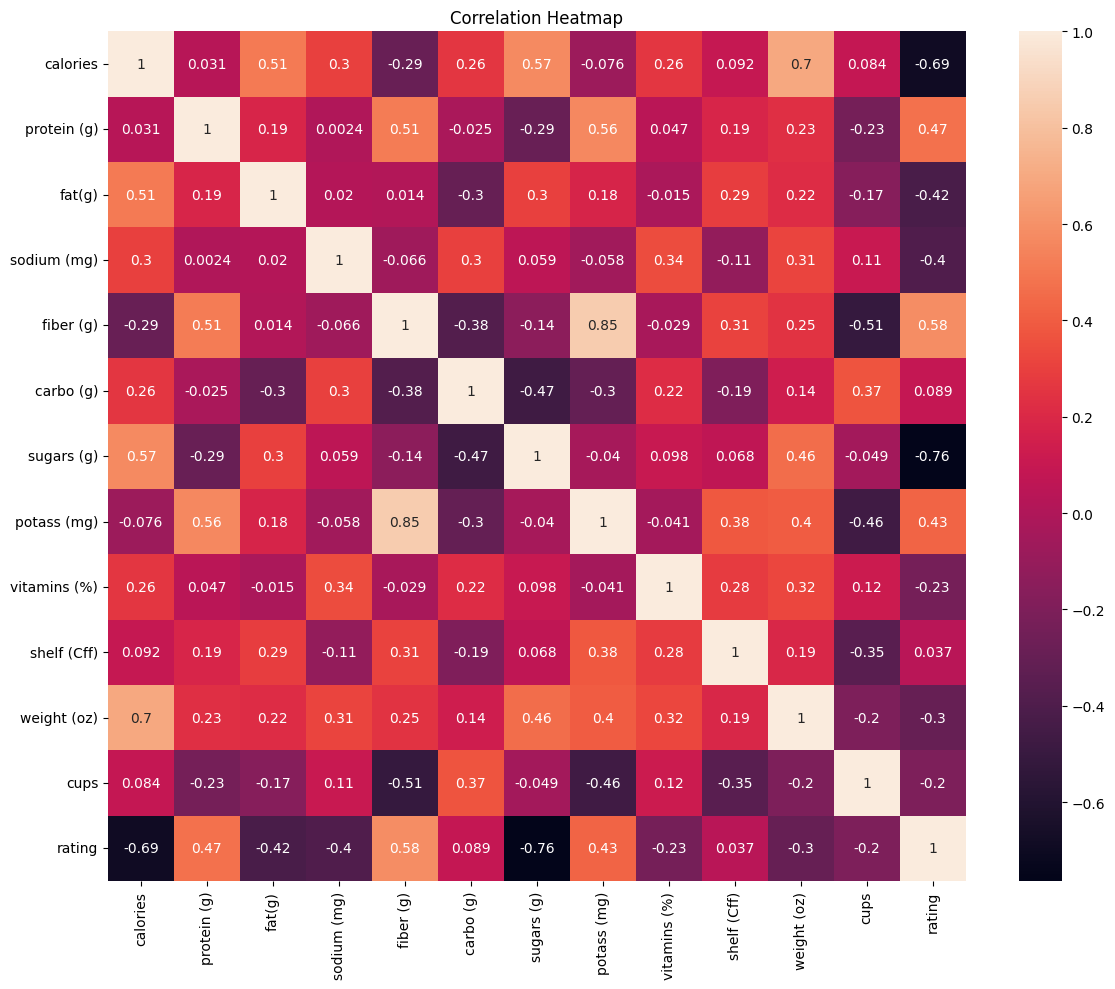

In [8]:
# Correlation between features

# Select numeric columns
df_numeric = df_q1[['calories', 'protein (g)', 'fat(g)',
       'sodium (mg)', 'fiber (g)', 'carbo (g)', 'sugars (g)', 'potass (mg)',
       'vitamins (%)', 'shelf (Cff)', 'weight (oz)', 'cups', 'rating']]

#Setting the plot
plt.figure(figsize=(12,10))
heatmap = sns.heatmap(df_numeric.corr(), annot=True)
heatmap.set_title('Correlation Heatmap')
plt.tight_layout()

#### From this plot, we can observe that:
- Calories and sugars show a strong **negative** correlation, meaning that the more sugar (and consequently, the more calories), the lower the rating tends to be.
- Fiber and protein show a moderate **positive** correlation, indicating that the more fiber and protein, the higher the rating tends to be.

<Axes: title={'center': 'Rating x Sugars/Calories'}, xlabel='sugars (g)', ylabel='calories'>

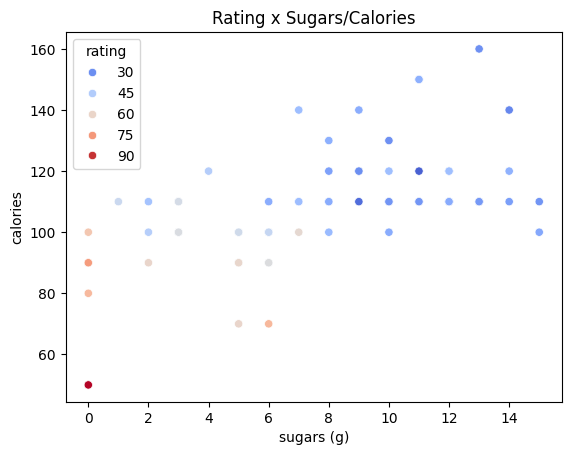

In [9]:
# Scatterplot to understand the correlation between rating x sugars/calories
plt.title("Rating x Sugars/Calories")
sns.scatterplot(data=df_q1, x="sugars (g)", y="calories", hue="rating", palette="coolwarm")

> "As the correlation heatmap indicated, this plot confirms the initial impression. As we can see, the closer the colors are to red, the higher the rating, and the lower the calories and sugar values."

<Axes: title={'center': 'Rating x Protein/Fiber'}, xlabel='protein (g)', ylabel='fiber (g)'>

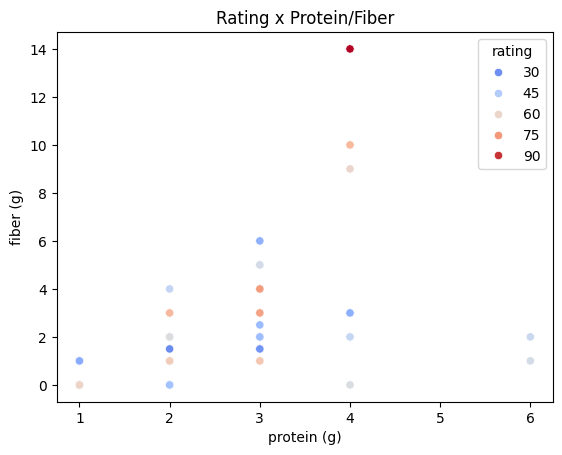

In [10]:
# Scatterplot to understand the correlation between rating x sugars/calories
plt.title("Rating x Protein/Fiber")
sns.scatterplot(data=df_q1, x="protein (g)", y="fiber (g)", hue="rating", palette="coolwarm")

> Here we understand why the correlation between them is moderate. There is no clearly defined pattern — some cereals with a rating between 60-75 show high fiber and protein values, while others do not. The only pattern observed was for cereals with a rating of 90+. However, considering the small number of records, this pattern cannot be confirmed.

### Distribution

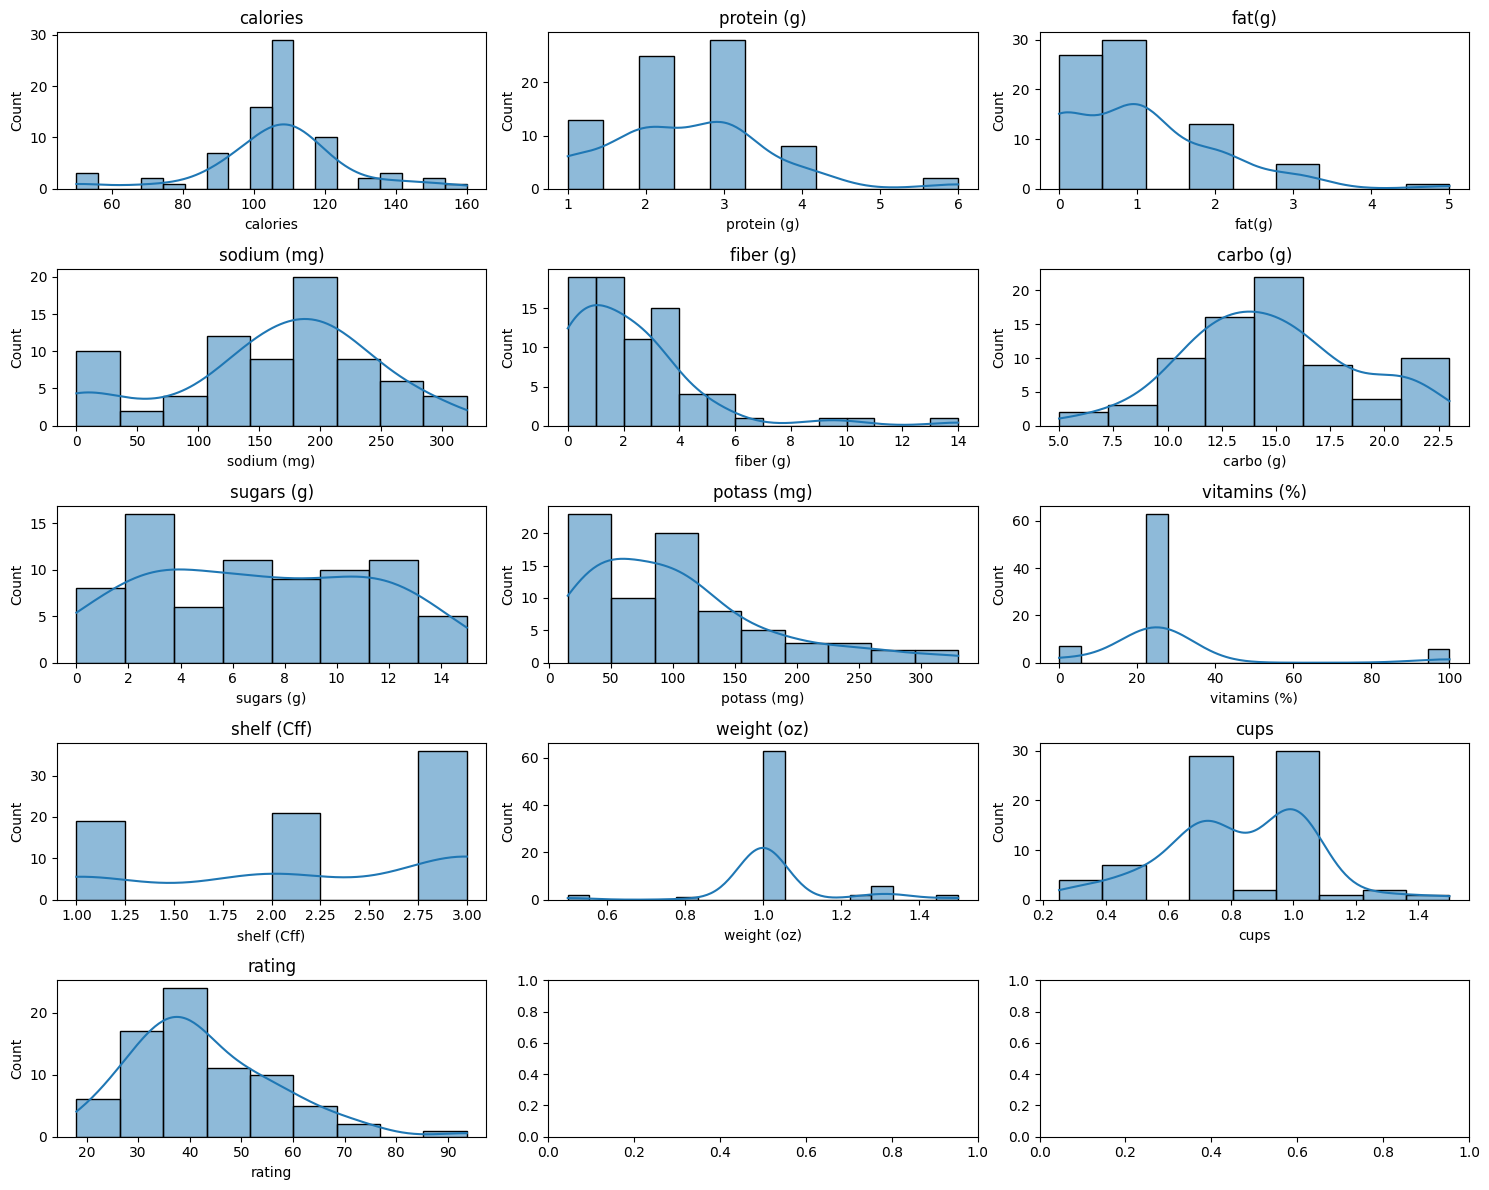

In [11]:
n_cols = 3                        # No of plots per row
cols = df_numeric.columns           # Df created just with numeric features

fig, axes = plt.subplots(5, n_cols, figsize = (15,12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df_q1[col], kde = True, ax = axes[i])
    axes[i].set_title(col)


plt.tight_layout()
plt.show()

#### The histplot confirmed some initial impressions:

- Rating (target): Slight skewness, as suggested based on the values (mean 42.56 > median 40.25).
- Protein: Step-like distribution, since the values are discrete, ranging between 1 and 6.
- Vitamins: Almost entirely concentrated at 25%, with an apparent outlier at 100%.
- Fiber & Potass: Strong positive (right) skewness with a fairly elongated tail. More pronounced than expected, considering the difference between mean and median.

### Outliers

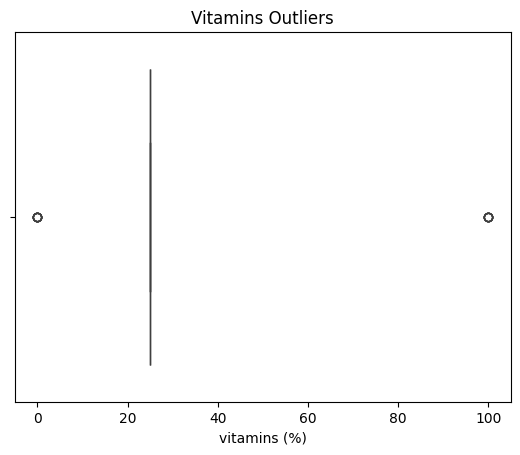

In [12]:
# Vitamin boxplot
plt.title("Vitamins Outliers")
sns.boxplot(x=df_q1["vitamins (%)"])
plt.show()

> This plot shows an unusual shape due to the uniformity of the data: almost all samples have a value of 25%, while only a few deviate from this pattern, with 7 samples at 0% and 6 at 100%.

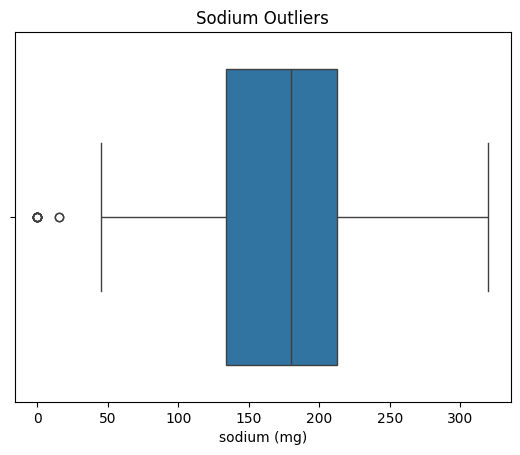

In [13]:
# Sodium boxplot
plt.title("Sodium Outliers")
sns.boxplot(x=df_q1["sodium (mg)"])
plt.show()

> The outliers found are concentrated at or near 0. This indicates that, in general, lower sodium tends to result in higher ratings. However, as seen in the feature correlation analysis, the correlation of -0.4 reinforces that despite this tendency, there are enough exceptions to make this correlation moderate, unlike other features.

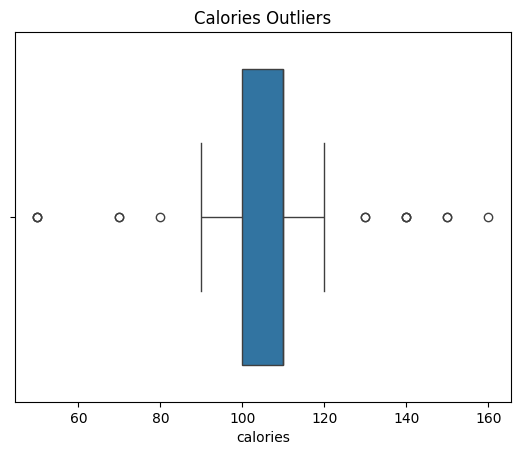

In [14]:
# Calories boxplot
plt.title("Calories Outliers")
sns.boxplot(x=df_q1["calories"])
plt.show()

> Although there are few records, it is clear that they show a wide variability in values. However, it indicates that values above Q3 tend to have a lower rating, while those below Q1 tend to have a higher rating. This visually illustrates what the correlation heatmap indicated earlier.

## Encoding

In [15]:
# View the features types
df_q1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          76 non-null     object 
 1   mfr           76 non-null     object 
 2   type          76 non-null     object 
 3   calories      76 non-null     int64  
 4   protein (g)   76 non-null     int64  
 5   fat(g)        76 non-null     int64  
 6   sodium (mg)   76 non-null     int64  
 7   fiber (g)     76 non-null     float64
 8   carbo (g)     76 non-null     float64
 9   sugars (g)    76 non-null     int64  
 10  potass (mg)   76 non-null     int64  
 11  vitamins (%)  76 non-null     int64  
 12  shelf (Cff)   76 non-null     int64  
 13  weight (oz)   76 non-null     float64
 14  cups          76 non-null     float64
 15  rating        76 non-null     float64
dtypes: float64(5), int64(8), object(3)
memory usage: 9.6+ KB


#### Pre-encoding explanation

Name, mfr, and type are strings, which is why I need to transform them into numeric values. However, Name has no relevance to this model, so I will only use mfr and type. Before starting the encoding, it is important to understand how many unique values exist in each, since this influences the chosen approach.

In [16]:
# Check unique values from 'mfr'
df_q1["mfr"].unique()

array(['Q', 'G', 'P', 'K', 'R', 'A', 'N'], dtype=object)

In [17]:
# Check unique values from 'type'
df_q1["type"].unique()

array(['C', 'H'], dtype=object)

In [18]:
# Encode 'mfr'
df_q1_encoded = pd.get_dummies(df_q1.drop(columns = ['name']), columns = ['mfr'], drop_first = True)

> I chose to use `pd.get_dummies` instead of `OneHotEncoder` (from scikit-learn) because this is a small, static dataset that will be transformed only once, without the need to apply the same encoding to new/unseen data later. `get_dummies` is simpler and faster to implement directly on the dataframe, while still avoiding the false hierarchy that Label Encoding would introduce.

In [19]:
# Encode 'type'
df_q1_encoded['type'] = df_q1_encoded['type'].map({'C': 0, 'H': 1}).astype(int)

> For the `type` feature, there are only 2 possible values. In this case, I used `.map()` to substitute the values with numbers, since with only two categories there is no risk of creating a false hierarchy.

In [20]:
df_q1_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   type          76 non-null     int64  
 1   calories      76 non-null     int64  
 2   protein (g)   76 non-null     int64  
 3   fat(g)        76 non-null     int64  
 4   sodium (mg)   76 non-null     int64  
 5   fiber (g)     76 non-null     float64
 6   carbo (g)     76 non-null     float64
 7   sugars (g)    76 non-null     int64  
 8   potass (mg)   76 non-null     int64  
 9   vitamins (%)  76 non-null     int64  
 10  shelf (Cff)   76 non-null     int64  
 11  weight (oz)   76 non-null     float64
 12  cups          76 non-null     float64
 13  rating        76 non-null     float64
 14  mfr_G         76 non-null     bool   
 15  mfr_K         76 non-null     bool   
 16  mfr_N         76 non-null     bool   
 17  mfr_P         76 non-null     bool   
 18  mfr_Q         76 non-null     bo

#### Encoding goal

The goal of this encoding step overall is to convert the columns into numeric values while avoiding unnecessary increases in dimensionality and false hierarchies where possible.

## Define X and y

In [21]:
X = df_q1_encoded.drop(columns = ['rating'])     # Independent features
y = df_q1_encoded['rating']                      # Dependent feature( target feature)

print(X.shape, y.shape)

(76, 19) (76,)


## Split the dataframe in Train and Test

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state=42)

## Pipeline + Scaling

In [23]:
# Libraries imports
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

# Create pipelines to organize and compare the models
models = {
    
    # LR model
    'pipe_lr': Pipeline([
        ('scaler', RobustScaler()),
        ('model', LinearRegression())
    ]),
    # PR model
    'pipe_pr': Pipeline([
        ('poly', PolynomialFeatures()),
        ('scaler', RobustScaler()),
        ('model', LinearRegression())
    ]),
    # RF model
    'pipe_rf': Pipeline([
        ('model', RandomForestRegressor(random_state=42))
    ])
}

# Parameters

# LR parameters
params_lr = {'model__fit_intercept': [True, False]}
    
# PR parameters
params_poly = {
    'poly__degree': [2],
    'model__fit_intercept': [True, False]
}
    
# RF parameters
params_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5]
}

# Add pipeline with the parameters
param_grids = {
    'pipe_lr': params_lr,
    'pipe_pr': params_poly,
    'pipe_rf': params_rf
}

### Pipeline Explanation

The 3 models being compared each contain more than one hyperparameter, with each hyperparameter having multiple possible values. With the help of GridSearchCV, we will test which configuration yields the best possible performance, based on the R² score.

**Scaling**:
- I chose RobustScaler over StandardScaler because EDA identified several outliers across various variables (e.g., calories, sodium, vitamins, weight). RobustScaler uses the median and the IQR, making it more robust and less sensitive to outliers.


**Parameters**:
- Fit_intercept — Defines whether the model will use the intercept as a basis for calculation.
- Degree — Defines the degree of the polynomial, i.e., up to which power the features will be raised, creating new features to help capture the behavior.
- Max_depth — Basically the number of levels of questions the whole tree can make (not per node). Important to understand the balance between overfitting, but also not leaving it too generalized.
- Min_samples_split — Minimum number of records a node needs to have in order to continue being split.

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

# Grid Search CV

results = {}         # Storage the results
trained_models = {}  # Storage the best model/parameters

# Loop through each model (Linear, Polynomial, Random Forest Regressor)    
for name, pipe in models.items():
    grid = GridSearchCV(pipe, param_grids[name], cv=5, scoring='r2')
    grid.fit(X_train, y_train)       # Train model with GridSearchCV
    preds = grid.predict(X_test)     # Predict target values for test data
    
    trained_models[name] = grid      # Store the trained model (best params already applied)
    
    # Store evaluation metrics and model parameters 
    mse = mean_squared_error(y_test, preds)         # Mean Squared Error
    
    results[name] = {
        "mse": mse,   
        "r2": r2_score(y_test, preds),               # R-squared score
        "rmse": np.sqrt(mse),                        # Root Mean Squared Error
        "best_params": grid.best_params_             # Best parameters found by GridSearchCV
    }
    
    # Store performance results for each model
    print(f"{name:6s} |RMSE = {results[name]['rmse']:.4f}| MSE = {results[name]['mse']:.4f}| R2 = {results[name]['r2']:.4f}| Best: {results[name]['best_params']}")

pipe_lr |RMSE = 1.7167| MSE = 2.9472| R2 = 0.9825| Best: {'model__fit_intercept': True}
pipe_pr |RMSE = 2.1136| MSE = 4.4671| R2 = 0.9735| Best: {'model__fit_intercept': True, 'poly__degree': 2}
pipe_rf |RMSE = 4.7651| MSE = 22.7065| R2 = 0.8653| Best: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


#### Meaning of each metric

**R²** — Measures the variability of the model. For example, we obtained 98.25%. That is, our model can explain approximately 98.3% of the variance of the rating. The disadvantage of this model is that outliers can mask a good result.

**Mean Squared Error (MSE)** — Because it is squared, errors are penalized differently; that is, very distant errors are heavily penalized. This is an advantage in models where the error is very costly (financial, health, etc.). However, for this reason, it becomes more difficult to interpret.

**Root Mean Squared Error (RMSE)** — Square root of the MSE. This brings the error back to the same unit as the rating, making it easier to interpret. RMSE = 1.71 means the model's predictions are, on average, about 1.71 points away from the actual rating.

### Result

| Model                  | RMSE   | MSE     | R²     |
|------------------------|--------|---------|--------|
| Linear Regression      | 1.7167 | 2.9472  | 0.9825 |
| Polynomial Regression  | 2.1136 | 4.4671  | 0.9735 |
| Random Forest          | 4.7651 | 22.7065 | 0.8653 |

Considering the metrics, using the Linear Regression model, we obtained an R² of 0.9825, which means the model explains 98.25% of the variance in rating. The RMSE indicates that, on average, the model's predictions differ from the actual values by about 1.71 points, whether higher or lower. The MSE metric, although useful, squares the errors, which strongly penalizes larger errors and makes the result more difficult to interpret directly.

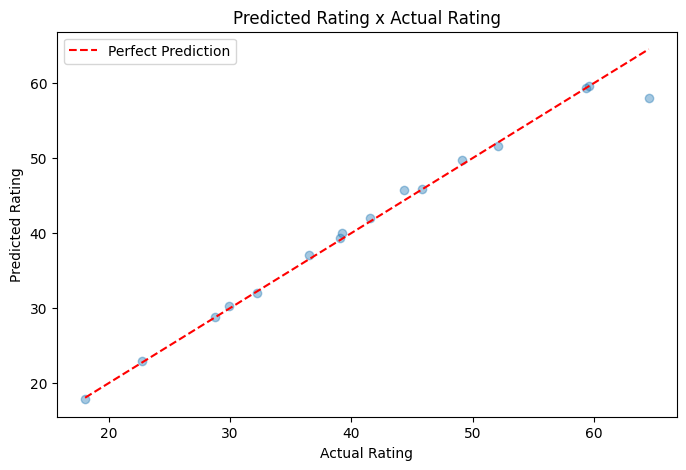

In [25]:
# Plot to understand how wrong/right the model is working
y_pred = trained_models['pipe_lr'].predict(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Predicted Rating x Actual Rating")
plt.legend()
plt.show()

## Conclusion

Comparing the three regression models, Linear Regression achieved the best performance across all metrics (R² = 0.9825, RMSE = 1.7167), followed closely by Polynomial Regression (R² = 0.9735, RMSE = 2.1136), while Random Forest performed the worst (R² = 0.8769, RMSE = 4.5551).

This result suggests that, since rating and all the features are related to different nutrients the body needs, there is likely an underlying formula behind it, assigning different weights to healthier or less healthy nutrients.

One factor that reinforces this possibility is the R² score above: Linear Regression achieved a performance of 98.25%, indicating strong linearity in the relationship between the features and the target. While the Polynomial model had more errors, it still achieved an excellent performance of 97.35%, whereas Random Forest was not able to capture this underlying formula as well.

However, it is important to highlight that the number of records is very low, indicating a limitation of the model.

# QUESTION 2

In [26]:
# Import libraries
import pandas as pd
import numpy as np

## Initial EDA

In [27]:
# Read and display the dataset
df_q2 = pd.read_csv("question2/OnlineNewsPopularity.csv")

df_q2.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


### Dataset Attributes (61 total: 58 predictive, 2 non-predictive, 1 target)

| Attribute | Description |
|---|---|
| `url` | URL of the article (non-predictive) |
| `timedelta` | Days between article publication and dataset acquisition (non-predictive) |
| `n_tokens_title` | Number of words in the title |
| `n_tokens_content` | Number of words in the content |
| `n_unique_tokens` | Rate of unique words in the content |
| `n_non_stop_words` | Rate of non-stop words in the content |
| `n_non_stop_unique_tokens` | Rate of unique non-stop words in the content |
| `num_hrefs` | Number of links |
| `num_self_hrefs` | Number of links to other Mashable articles |
| `num_imgs` | Number of images |
| `num_videos` | Number of videos |
| `average_token_length` | Average length of the words in the content |
| `num_keywords` | Number of keywords in the metadata |
| `data_channel_is_lifestyle` | Is data channel 'Lifestyle'? |
| `data_channel_is_entertainment` | Is data channel 'Entertainment'? |
| `data_channel_is_bus` | Is data channel 'Business'? |
| `data_channel_is_socmed` | Is data channel 'Social Media'? |
| `data_channel_is_tech` | Is data channel 'Tech'? |
| `data_channel_is_world` | Is data channel 'World'? |
| `kw_min_min` | Worst keyword (min. shares) |
| `kw_max_min` | Worst keyword (max. shares) |
| `kw_avg_min` | Worst keyword (avg. shares) |
| `kw_min_max` | Best keyword (min. shares) |
| `kw_max_max` | Best keyword (max. shares) |
| `kw_avg_max` | Best keyword (avg. shares) |
| `kw_min_avg` | Avg. keyword (min. shares) |
| `kw_max_avg` | Avg. keyword (max. shares) |
| `kw_avg_avg` | Avg. keyword (avg. shares) |
| `self_reference_min_shares` | Min. shares of referenced Mashable articles |
| `self_reference_max_shares` | Max. shares of referenced Mashable articles |
| `self_reference_avg_sharess` | Avg. shares of referenced Mashable articles |
| `weekday_is_monday` ... `weekday_is_sunday` | Was the article published on that weekday? |
| `is_weekend` | Was the article published on the weekend? |
| `LDA_00` ... `LDA_04` | Closeness to LDA topics 0–4 |
| `global_subjectivity` | Text subjectivity |
| `global_sentiment_polarity` | Text sentiment polarity |
| `global_rate_positive_words` | Rate of positive words in the content |
| `global_rate_negative_words` | Rate of negative words in the content |
| `rate_positive_words` | Rate of positive words among non-neutral tokens |
| `rate_negative_words` | Rate of negative words among non-neutral tokens |
| `avg_positive_polarity` | Avg. polarity of positive words |
| `min_positive_polarity` | Min. polarity of positive words |
| `max_positive_polarity` | Max. polarity of positive words |
| `avg_negative_polarity` | Avg. polarity of negative words |
| `min_negative_polarity` | Min. polarity of negative words |
| `max_negative_polarity` | Max. polarity of negative words |
| `title_subjectivity` | Title subjectivity |
| `title_sentiment_polarity` | Title polarity |
| `abs_title_subjectivity` | Absolute subjectivity level |
| `abs_title_sentiment_polarity` | Absolute polarity level |
| `shares` | Number of shares (**target**) |

In [28]:
df_q2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

In [29]:
# Check null values
df_q2.isnull().sum()

url                              0
 timedelta                       0
 n_tokens_title                  0
 n_tokens_content                0
 n_unique_tokens                 0
                                ..
 title_subjectivity              0
 title_sentiment_polarity        0
 abs_title_subjectivity          0
 abs_title_sentiment_polarity    0
 shares                          0
Length: 61, dtype: int64

In [30]:
# Check duplicates
df_q2.duplicated().sum()

np.int64(0)

In [31]:
# Check duplicates
df_q2["url"].duplicated().sum()

np.int64(0)

> There are no null or duplicate values. The 'url' column was also checked, as it serves as a unique identifier, yet no duplicates were found.

In [32]:
# Display columns names
df_q2.columns

Index(['url', ' timedelta', ' n_tokens_title', ' n_tokens_content',
       ' n_unique_tokens', ' n_non_stop_words', ' n_non_stop_unique_tokens',
       ' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos',
       ' average_token_length', ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sent

> As shown above, several column names contain unnecessary whitespace at the beginning or end, which can cause errors during processing. To prevent this, we use a method that strips leading and trailing spaces from the column names.

In [33]:
# Remove spaces before/after character
df_q2.columns = df_q2.columns.str.strip()

In [34]:
# View the names with the changes
df_q2.columns

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

### Target Feature
When analyzing the existing features in the dataset, we noticed there is no categorical variable suitable as a target for a classification model. The feature that comes closest is `shares`, since it represents how popular an article became. However, as it is numerical and continuous, it must be transformed by creating categories (e.g., "popular" and "not popular") based on a criterion, which will be defined once we better understand the feature.

In [35]:
# Shares statistical summary
df_q2['shares'].describe()

count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name: shares, dtype: float64

> The statistical summary indicates strong positive (right) skewness, evidenced by the large gap between the mean (3395.38) and the median (1400). There is also strong data dispersion, with a standard deviation of 11626.95. This apparently suggests the presence of outliers, which will be examined in more detail using graphical visualization.

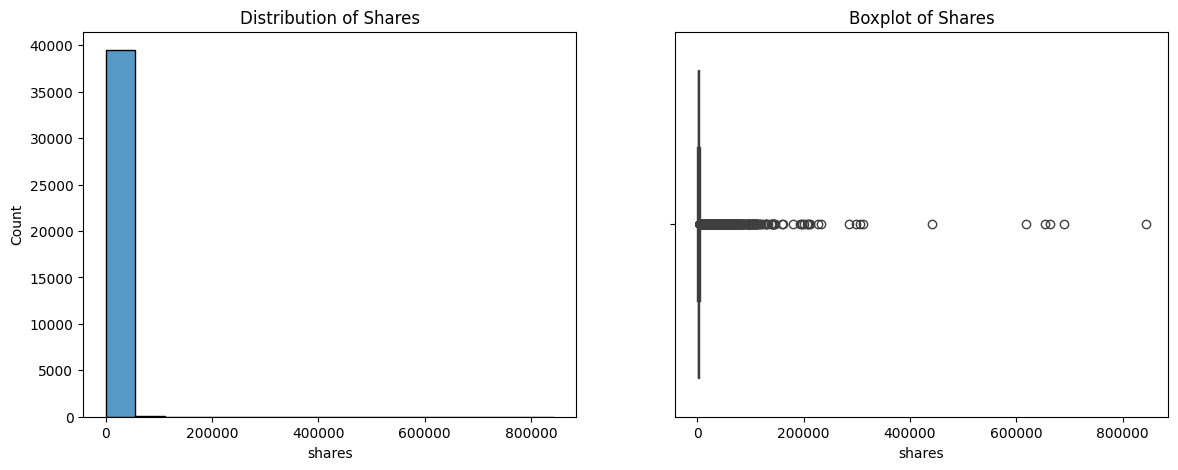

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize = (14, 5))
# Plot the distribution
sns.histplot(df_q2['shares'], bins = 15, ax=axes[0])
axes[0].set_title('Distribution of Shares')

# Plot the outliers
sns.boxplot(x=df_q2['shares'], ax=axes[1])
axes[1].set_title('Boxplot of Shares')
plt.show()

#### Visualization Conclusion

> The graphs confirm the strong presence of outliers and the high asymmetry of the data. 

- From the **histogram**, it was possible to identify this asymmetry: most values are concentrated up to approximately 4000 shares, however, due to the presence of outliers, the axis needs to include much higher values, such as 843,300, which makes the visualization unusual. 
- The **boxplot** confirms this reading, showing a large number of points beyond the upper limit. It is worth noting that this behavior is natural nowadays — news that goes viral receives a number of views far above average, which makes this pattern expected.

## Create Target Feature

In [37]:
# Display quartiles values
q1 = df_q2['shares'].quantile(0.25)
q2 = df_q2['shares'].quantile(0.50)  # median
q3 = df_q2['shares'].quantile(0.75)

print(f"Q1 (25%): {q1}")
print(f"Q2 (50% - median): {q2}")
print(f"Q3 (75%): {q3}")

Q1 (25%): 946.0
Q2 (50% - median): 1400.0
Q3 (75%): 2800.0


### Classification Feature Creation

> Using the quartiles as justification, plus a percentage applied to that value in order to actually differentiate popular news from viral ones, three classes will be created: not popular, popular, and very popular. As seen in the graphs, some news articles have an extremely high number of views, so it does not make sense to place them in the same category as articles that stay around the average.

- Not popular: shares ≤ 946 (Q1)
- Popular: 946 < shares ≤ 3080 (Q3 + 10%)
- Very popular: shares > 3080

In [38]:
# Create the target feature
condlist = [
    df_q2['shares'] <= 946,
    (df_q2['shares'] > 946) & (df_q2['shares'] <= 3080),
    df_q2['shares'] > 3080
]

# labels name
label = ['not popular', 'popular', 'very popular']

# Apply the conditions
df_q2['popularity'] = np.select(condlist, label, default='unknown')

In [39]:
# Check output
df_q2['popularity'].head(10)

0     not popular
1     not popular
2         popular
3         popular
4     not popular
5     not popular
6     not popular
7     not popular
8    very popular
9     not popular
Name: popularity, dtype: object

> Considering the model's performance, it is important to verify whether the data is balanced, in order to ensure that none of the classes is considered less important and introduces bias into the result.

In [40]:
# View the balance of the classes
df_q2['popularity'].value_counts()

popularity
popular         20788
not popular      9930
very popular     8926
Name: count, dtype: int64

> Despite this disparity, using the 'stratify' parameter, this is not expected to be a problem; however, if it does not work as expected, another approach will be taken.

## Define X and y

In [41]:
# timedelta, url and shares will be dropped
# Shares feature was useful to classify the records into three classes, so it is not important anymore

X = df_q2.drop(columns=['timedelta', 'url', 'shares', 'popularity'])
y = df_q2['popularity']

### Symmetry / Asymmetry
Due to the large number of features, in order to avoid plotting numerous graphs with similar patterns, `.skew()` was used to understand how symmetric or asymmetric the data is.

In general:
- **Skew = 0** indicates symmetric data
- **Skew < 0** indicates negative skewness
- **Skew > 0** indicates positive skewness

In [42]:
# Compute the sample skewness of a data set
X.skew().sort_values(ascending=False).head(10)

n_non_stop_words              198.792445
n_unique_tokens               198.655116
n_non_stop_unique_tokens      198.443294
kw_max_min                     35.328434
kw_avg_min                     31.306108
self_reference_min_shares      26.264364
self_reference_avg_sharess     17.914093
kw_max_avg                     16.411670
self_reference_max_shares      13.870849
kw_min_max                     10.386372
dtype: float64

> Listing the top 10, we see strong positive skewness across many features, reinforcing that the best way to handle this dataset is by using RobustScaler, as it deals better with outliers and is less sensitive to them.

However, the columns with the highest skew stand out, so they will be checked in more detail.

In [43]:
# View statistic summary from these features
X[['n_non_stop_words', 'n_unique_tokens', 'n_non_stop_unique_tokens']].describe()

,n_non_stop_words,n_unique_tokens,n_non_stop_unique_tokens
count,39644.000000,39644.000000,39644.000000
mean,0.996469,0.548216,0.689175
std,5.231231,3.520708,3.264816
min,0.000000,0.000000,0.000000
25%,1.000000,0.470870,0.625739
50%,1.000000,0.539226,0.690476
75%,1.000000,0.608696,0.754630
max,1042.000000,701.000000,650.000000


> As indicated in the statistical summary, this suggests a data error, considering that Q3 = 1, std = 5.23, and max = 1042 (considering the lowest value among the three columns).

## Train & Test

In [44]:
from sklearn.model_selection import train_test_split

# Split into Train & Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, shuffle = True, stratify = y)

In [45]:
# Check if the train & test is working
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((31715, 58), (7929, 58), (31715,), (7929,))

## Modelling

In [46]:
# Libraries imports
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


# Create pipelines to organize and compare the models
models = {
    
    # LR model
    'pipe_lr': Pipeline([
        ('scaler', RobustScaler()),
        ('model', LogisticRegression(class_weight = 'balanced', max_iter = 1000))
    ]),
    
    # RF model
    'pipe_rf': Pipeline([
        ('model', RandomForestClassifier(class_weight = 'balanced', random_state=42))
    ]),
    
     # KNN model
    'pipe_knn': Pipeline([
    ('scaler', RobustScaler()),
    ('model', KNeighborsClassifier())
])
}

# Parameters

# LR parameters
params_lr = {'model__C': [0.01, 0.1 , 1, 10]}            # Differents value for regularization
    
# RF parameters
params_rf = {
    'model__n_estimators': [50, 100, 200],               # No of trees
    'model__max_depth': [None, 5, 10],                   # Tree depth limit
    'model__min_samples_split': [2, 5]                   # Min samples to split a node
}
    
# KNN parameters
params_knn = {
    'model__n_neighbors': [3, 5, 7, 9],                   # Number of neighbors
    'model__weights': ['uniform', 'distance']             # Vote type: equal or distance-based
}

# Add pipeline with the parameters
param_grids = {
    'pipe_lr': params_lr,
    'pipe_rf': params_rf,
    'pipe_knn': params_knn
}

In [47]:
# Grid Search CV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

results = {}         # Storage the results
trained_models = {}  # Storage the best model/parameters

# Loop through each model (Logistic Regression, Random Forest, KNN)
for name, pipe in models.items():
    grid = GridSearchCV(pipe, param_grids[name], cv=5, scoring='f1_weighted')
    grid.fit(X_train, y_train)       # Train model with GridSearchCV
    preds = grid.predict(X_test)     # Predict target values for test data
    
    trained_models[name] = grid      # Store the trained model (best params already applied)
    
    # Store evaluation metrics and model parameters
    acc = accuracy_score(y_test, preds)               # Accuracy score
    f1 = f1_score(y_test, preds, average='weighted')  # F1 score (weighted by class size)
    
    results[name] = {
        "accuracy": acc,
        "f1_weighted": f1,
        "best_params": grid.best_params_              # Best parameters found by GridSearchCV
    }
    
    # Print performance results for each model
    print(f"{name:8s} | Accuracy = {results[name]['accuracy']:.4f} | F1 = {results[name]['f1_weighted']:.4f} | Best: {results[name]['best_params']}")

pipe_lr  | Accuracy = 0.3761 | F1 = 0.3783 | Best: {'model__C': 0.01}
pipe_rf  | Accuracy = 0.5515 | F1 = 0.5070 | Best: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 50}
pipe_knn | Accuracy = 0.4997 | F1 = 0.4705 | Best: {'model__n_neighbors': 9, 'model__weights': 'distance'}


## Evaluation

### Classification Report

In [48]:
# Generate classification report for the best model (Random Forest)
preds_rf = trained_models['pipe_rf'].predict(X_test)
print(classification_report(y_test, preds_rf))

              precision    recall  f1-score   support

 not popular       0.53      0.28      0.37      1986
     popular       0.56      0.83      0.67      4158
very popular       0.47      0.19      0.28      1785

    accuracy                           0.55      7929
   macro avg       0.52      0.44      0.44      7929
weighted avg       0.54      0.55      0.51      7929



#### Classification Report results
- **Precision** - When the model predicts a class, how accurate is it?

- **Recall** - Of all the examples of the class in question, how many were found?

- **F1-score** - Harmonic mean between precision and recall

- **Support** - Number of samples

As indicated in the report, the best-performing model (Random Forest) shows that:

- **Popular** is the category with the highest accuracy rate: both precision and recall show values close to 0.60. Although not the ideal value, it is the best performance among the three classes. This balance is confirmed by the F1-score, since it would not make sense to have high precision paired with low recall (or vice versa).

- With different values, this same pattern of balance between metrics occurs in both "not popular" and "very popular" — however, despite the balanced F1-score, neither class exceeds 0.47.

- There is, however, a limitation: the support values show that there are 2.09x more samples of "popular" compared to "not popular", and 2.33x more compared to "very popular". Although the `stratify` parameter helps maintain this proportion between training and test sets, the disparity itself (which already existed in the original data) remains a limitation of the dataset.

It is also worth noting the difference between the *weighted avg* (0.52) and the *macro avg* (0.49). This clearly highlights the class imbalance already identified previously. For this reason, the `stratify` parameter was used to prevent an even greater drop in performance — even though the disparity itself is, in and of itself, a limitation of the dataset.

### Confusion Matrix

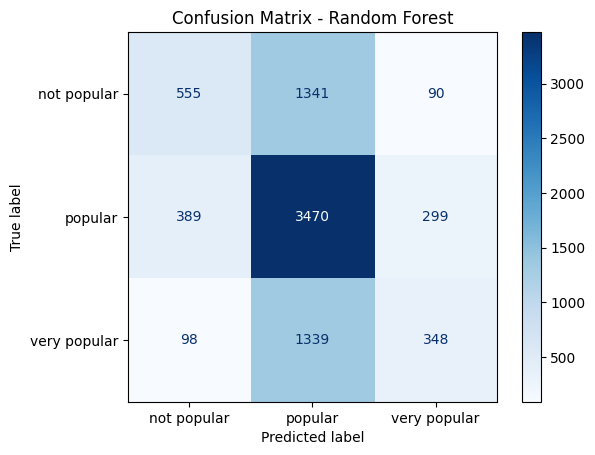

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_estimator(
    trained_models['pipe_rf'],
    X_test,
    y_test,
    cmap=plt.cm.Blues,
)
disp.ax_.set_title("Confusion Matrix - Random Forest")

plt.show()

#### Confusion Matrix results
The fact that 3 classes were introduced into the model increased the complexity of the task; however, it is still important to understand the difference between a viral news article and a popular one.

The confusion matrix reveals distinct error patterns for each class:

- **Not popular**: the model has difficulty distinguishing this class from "popular" — 936 correct predictions (47.1%) against 850 confusions with "popular" (42.8%), numbers that are quite close to each other.
- **Popular**: despite the large number of correct predictions (2503, or 60.2%), there are around 40% errors, split between confusion with "not popular" (873) and "very popular" (782).
- **Very popular**: the model makes few errors when compared with "not popular" (216 cases, 12.1%), but shows significant difficulty distinguishing it from "popular" (874 cases, 48.9%).

## Conclusion

With the creation of the `popularity` feature, it was possible to classify news articles into 3 classes (not popular, popular, very popular), which added more complexity to the model, rather than a simple binary analysis. As a criterion to define where each article falls, quartiles were used as a reference, adding an extra percentage to the "very popular" category, with the goal of differentiating "very popular" from "popular".

Three models were trained using GridSearchCV, and Random Forest was the one that showed the best performance. Comparing the three models, Random Forest achieved the best results (accuracy = 0.55, F1-score = 0.51), followed by KNN (accuracy = 0.50, F1 = 0.47), while Logistic Regression performed much worse (accuracy = 0.38, F1 = 0.38). This illustrates that the data does not show a linear relationship, which is why the other models achieved better performance.

Based on the confusion matrix and the classification report, a significant difficulty was identified in distinguishing "popular" from "very popular", with nearly 50% of samples confused between these two classes. This shows that, despite the difference in shares values, the remaining features do not show as much difference between these two groups, which is one of the causes of the lower performance.

The same model could be tested with some variations — instead of defining "very popular" as Q3 + 10% (3080), Q3 + 20% or even higher values could be used. However, even with just +10%, a relevant disparity in the number of samples was already found (popular = 20,788 x not popular = 9,930); therefore, the higher the percentage applied, the greater the imbalance tends to be, which directly affects performance. As a way to reduce this limitation, the `stratify` parameter was used.

# QUESTION 3

In [50]:
# Read and display the dataset
df_q3 = pd.read_csv("question3/Dry_Bean_Dataset.csv")

df_q3.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## Initial EDA

### Dataset Attributes (17 total: 16 features, 1 target)

| Attribute | Role | Type | Description | Units |
|---|---|---|---|---|
| `Area` | Feature | Integer | The area of a bean zone and the number of pixels within its boundaries | pixels |
| `Perimeter` | Feature | Continuous | Bean circumference, defined as the length of its border | — |
| `MajorAxisLength` | Feature | Continuous | Distance between the ends of the longest line that can be drawn from a bean | — |
| `MinorAxisLength` | Feature | Continuous | Longest line that can be drawn from the bean while standing perpendicular to the main axis | — |
| `AspectRatio` | Feature | Continuous | Relationship between MajorAxisLength and MinorAxisLength | — |
| `Eccentricity` | Feature | Continuous | Eccentricity of the ellipse having the same moments as the region | — |
| `ConvexArea` | Feature | Integer | Number of pixels in the smallest convex polygon that can contain the area of a bean seed | — |
| `EquivDiameter` | Feature | Continuous | Diameter of a circle having the same area as a bean seed area | — |
| `Extent` | Feature | Continuous | Ratio of the pixels in the bounding box to the bean area | — |
| `Solidity` | Feature | Continuous | Also known as convexity; ratio of the pixels in the convex shell to those found in the bean | — |
| `Roundness` | Feature | Continuous | Calculated as (4πA)/(P²) | — |
| `Compactness` | Feature | Continuous | Measures the roundness of an object | Ed/L |
| `ShapeFactor1` | Feature | Continuous | — | — |
| `ShapeFactor2` | Feature | Continuous | — | — |
| `ShapeFactor3` | Feature | Continuous | — | — |
| `ShapeFactor4` | Feature | Continuous | — | — |
| `Class` | **Target** | Categorical | Bean type (Seker, Barbunya, Bombay, Cali, Dermason, Horoz, Sira) | — |

In [51]:
df_q3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [52]:
df_q3.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


#### Descriptive Statistics Initial Insights

Analyzing the `Area` feature, there is a large dispersion in the data (std = 29,324.09), while the mean is 53,048 and the median is 44,652. In other words, the standard deviation represents about 55% of the mean and 66% of the median.

Comparing the Q3 (75%) values with the differences between median and mean, this indicates a large presence of outliers, which will be checked later for confirmation.

The `Solidity` feature shows low variation, ranging between 0.919246 (min) and 0.994677 (max).

In [53]:
# Check null values
df_q3.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [54]:
# Check duplicates
df_q3.duplicated().sum()

np.int64(68)

In [55]:
# Drop Duplicates
df_q3 = df_q3.drop_duplicates()

> No null values and the duplicates were deleted.

In [56]:
# Display the columns
df_q3.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='object')

## Visualizations

In [57]:
# Create a numeric dataset
df_q3_numeric = df_q3.drop(columns = ['Class'])

### Correlation

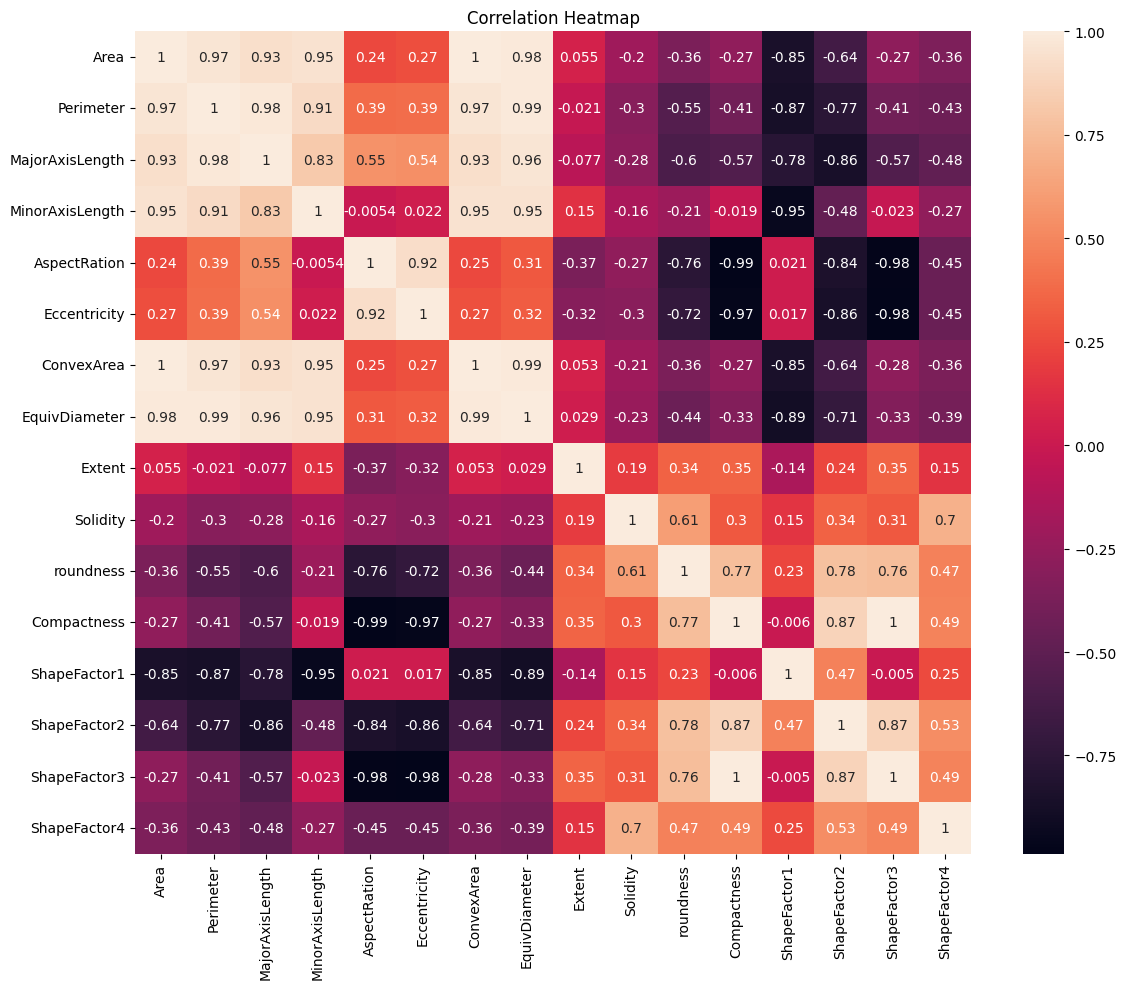

In [58]:
# Correlation between features

#Setting the plot
df_corr = df_q3_numeric
plt.figure(figsize=(12,10))
heatmap = sns.heatmap(df_corr.corr(), annot=True)
heatmap.set_title('Correlation Heatmap')
plt.tight_layout()

> This correlation heatmap clearly highlights the importance of understanding multicollinearity and how to deal with it. Saying that high collinearity exists means that different variables are conveying very similar information, and in practice, besides not adding new information, this makes the model heavier to run. The solution will be presented throughout the code.

### Outliers

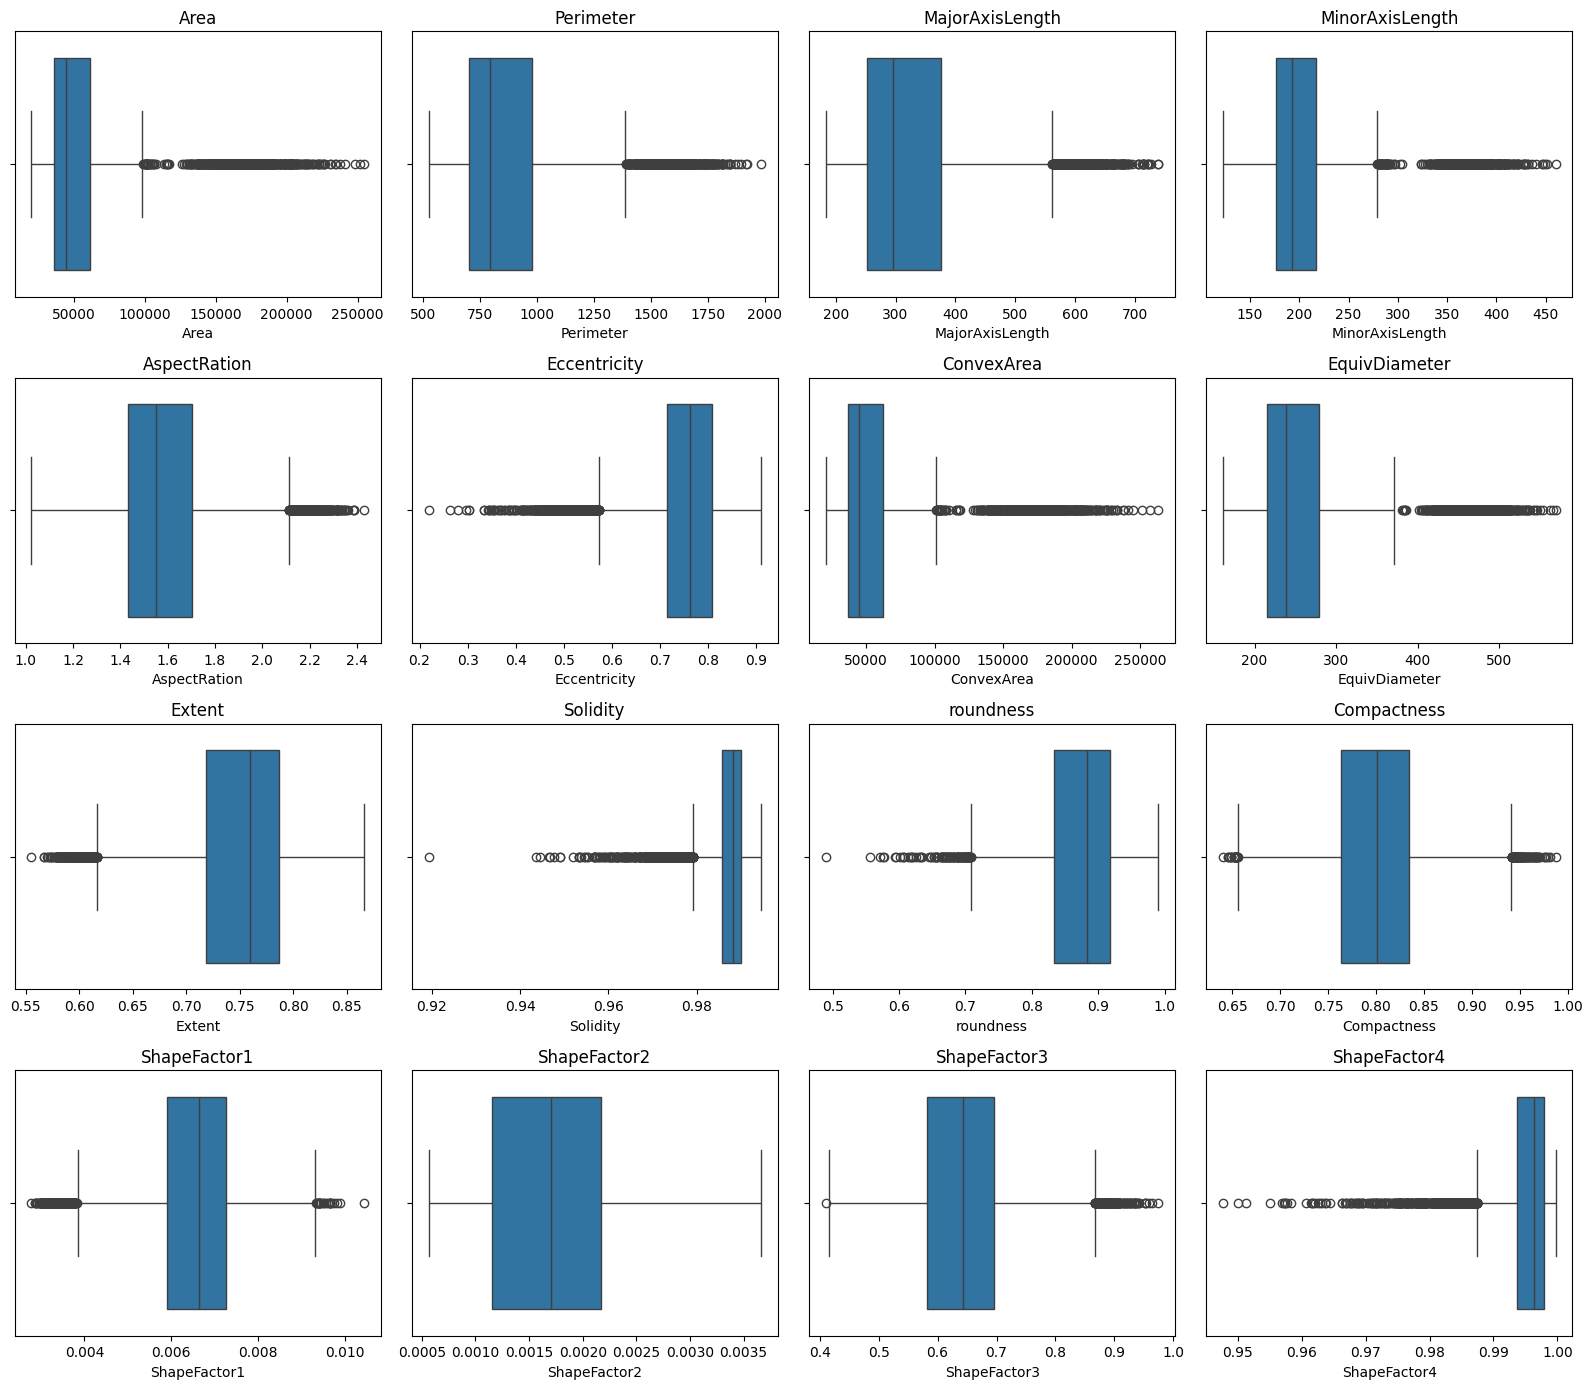

In [59]:
# Plotting outliers
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for ax, col in zip(axes.flatten(), df_q3_numeric):
    sns.boxplot(x=df_q3[col], ax=ax)
    ax.set_title(col)
    
plt.tight_layout()
plt.show()

Since this dataset involves different types of beans, the high number of outliers, combined with two clear patterns — half of the plots showing outliers on the left, while the other half show outliers on the right — indicates that the data considered as outliers are not errors, but rather different information, from beans that present quite different characteristics from one another. However, further plots and tests are needed to confirm this.

In [60]:
# Checking if there a huge different between them comparing the area
df_q3.groupby('Class')['Area'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
BARBUNYA,1322.0,69804.133132,10265.386454,41487.0,62931.00,69582.0,76306.50,115967.0
BOMBAY,522.0,173485.059387,23327.688116,114004.0,156711.25,171494.5,186599.00,254616.0
CALI,1630.0,75538.211043,9379.881487,45504.0,69343.50,74791.5,81304.75,116272.0
DERMASON,3546.0,32118.710942,4676.129470,20420.0,28549.25,31890.0,35581.00,42159.0
HOROZ,1860.0,53671.732796,7323.243875,33006.0,48958.00,53797.0,58545.00,81929.0
SEKER,2027.0,39881.299951,4779.877395,28395.0,36408.00,39180.0,42700.00,61150.0
SIRA,2636.0,44729.128604,4546.769886,31519.0,41612.00,44593.0,47772.00,63612.0


> Analyzing the results for the 7 bean types, particularly the **maximum**, **minimum**, and **median** values, confirms that there is a large size difference between the different types. As a comparison, while **DERMASON** has a maximum area of **42,159 pixels**, **BOMBAY** has a minimum area of **114,004.0 pixels**.

In [61]:
# Check the distribution of the Class feature
df_q3['Class'].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

## Scaling

As a scaling technique, two methods will be used: **RobustScaler** and **StandardScaler**.

**RobustScaler** was chosen considering the outliers identified previously and the fact that PCA is sensitive to this type of data — using a more robust method in this regard may improve performance.

**StandardScaler**, on the other hand, will be used based on the opposite assumption: although it is not the most suitable scaling method for handling outliers, these values are precisely what highlight the differences between bean types. In other words, this second approach assumes that the outliers carry valuable information for the problem, and therefore should not be smoothed out before PCA.

In [62]:
from sklearn.preprocessing import RobustScaler, StandardScaler

# Robust Scaler
scaler_robust = RobustScaler()
df_q3_robust = scaler_robust.fit_transform(df_q3_numeric)

# Standard Scaler
scaler_standard = StandardScaler()
df_q3_standard = scaler_standard.fit_transform(df_q3_numeric)

In [63]:
# Display robust scalled values
df_q3_robust

array([[-0.64483356, -0.67029551, -0.71597471, ...,  1.42639735,
         1.68505147,  0.55865635],
       [-0.63132732, -0.56907123, -0.77808287, ...,  1.83684024,
         2.34948574,  0.48828343],
       [-0.60558975, -0.61984583, -0.67825519, ...,  1.3282503 ,
         1.6116766 ,  0.64070143],
       ...,
       [-0.09725293, -0.1262246 , -0.12062957, ...,  0.1851974 ,
         0.30274934,  0.08960622],
       [-0.0969342 , -0.10994956, -0.10567564, ...,  0.14946436,
         0.22677652, -0.28073008],
       [-0.0964561 , -0.07907154, -0.01024014, ..., -0.05974533,
        -0.23021323,  0.42818268]], shape=(13543, 16))

In [64]:
# Display standard scalled values
df_q3_standard

array([[-0.83879977, -1.13966273, -1.30197615, ...,  2.39827967,
         1.92481096,  0.83867856],
       [-0.82726577, -1.01052862, -1.39116937, ...,  3.09747157,
         2.69144644,  0.77114129],
       [-0.80528652, -1.07530293, -1.24780735, ...,  2.23108558,
         1.8401498 ,  0.91741766],
       ...,
       [-0.37117925, -0.44557909, -0.44700409, ...,  0.28388814,
         0.32988743,  0.38852865],
       [-0.37090706, -0.42481666, -0.42552883, ...,  0.2230167 ,
         0.24222869,  0.03311492],
       [-0.37049878, -0.38542487, -0.2884744 , ..., -0.13337325,
        -0.28505379,  0.71346228]], shape=(13543, 16))

## Apply PCA

### PCA - RobustScaler

In [65]:
from sklearn.decomposition import PCA

# Robust Scaller
pca_robust = PCA()
pca_robust.fit(df_q3_robust)

explained_variance_robust = pca_robust.explained_variance_ratio_
cumulative_variance_robust = np.cumsum(explained_variance_robust)

print("=== RobustScaler ===")
print("Explained variance per component:", explained_variance_robust)     # Individual variance ratio for each component
print(f"\nCumulative variance:", cumulative_variance_robust)              # Total of explained variance

=== RobustScaler ===
Explained variance per component: [5.51168134e-01 2.66560792e-01 1.00568141e-01 3.43672154e-02
 2.60594201e-02 1.16924408e-02 6.13192203e-03 2.91078287e-03
 3.61022526e-04 9.48887497e-05 6.35035488e-05 1.42395554e-05
 6.32152247e-06 9.46340309e-07 1.23279732e-07 1.06301796e-07]

Cumulative variance: [0.55116813 0.81772893 0.91829707 0.95266428 0.9787237  0.99041614
 0.99654807 0.99945885 0.99981987 0.99991476 0.99997826 0.9999925
 0.99999882 0.99999977 0.99999989 1.        ]


> Analyzing the output generated by `explained_variance_robust` and `cumulative_variance_robust`, although useful, it becomes harder to actually visualize the message these numbers are conveying. Therefore, with the help of a plot, it is possible to make it more visual and informative.

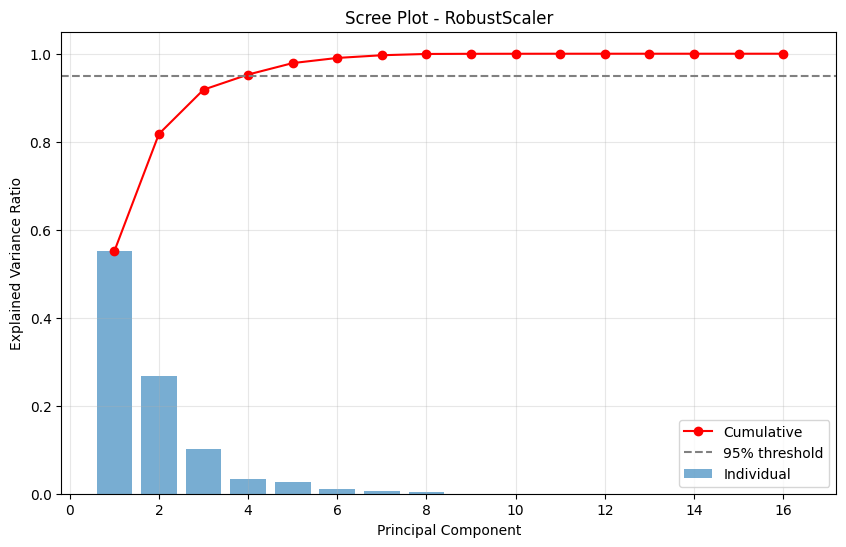

In [66]:
plt.figure(figsize=(10, 6))                             # Size
plt.bar(range(1, len(explained_variance_robust)+1), explained_variance_robust, alpha=0.6, label='Individual') # Setting bar
plt.plot(range(1, len(cumulative_variance_robust)+1), cumulative_variance_robust, marker = 'o', color = 'red', label = 'Cumulative') # Setting line
plt.axhline(y = 0.95, color = 'gray', linestyle = '--', label = '95% threshold')
plt.xlabel('Principal Component')                       # X label title
plt.ylabel('Explained Variance Ratio')                  # y label title
plt.title('Scree Plot - RobustScaler')                  # title
plt.legend()                                            # Add legend
plt.grid(axis='both', alpha=0.3)                        # Add grid to improve the visualization
plt.show()                                              # display the plot

#### Robust Scaler Conclusion

From this graph, it can be seen that with 4 components, 95% of explained variance is reached, with minimal gains for each additional component from that point on.

It is worth noting that keeping these components with low real information introduces noise that could harm the model during the clustering stage. 

### PCA - Standard Scaler

In [67]:
# Standard Scaller
pca_standard = PCA()
pca_standard.fit(df_q3_standard)

explained_variance_standard = pca_standard.explained_variance_ratio_
cumulative_variance_standard = np.cumsum(explained_variance_standard)

print("=== StandardScaler ===")
print("Explained variance per component:", explained_variance_standard)  # Individual variance ratio for each component
print("Cumulative variance:", cumulative_variance_standard)              # Total of explained variance

=== StandardScaler ===
Explained variance per component: [5.55468083e-01 2.63607889e-01 7.98440356e-02 5.10843828e-02
 2.75310113e-02 1.15217173e-02 6.98225217e-03 3.25959675e-03
 5.15105419e-04 9.09780750e-05 6.63526466e-05 1.84015899e-05
 9.32459680e-06 6.24825735e-07 1.34043057e-07 1.11033754e-07]
Cumulative variance: [0.55546808 0.81907597 0.89892001 0.95000439 0.9775354  0.98905712
 0.99603937 0.99929897 0.99981407 0.99990505 0.9999714  0.99998981
 0.99999913 0.99999975 0.99999989 1.        ]


> Analyzing the output generated by `explained_variance_standard` and `cumulative_variance_standard`, although useful, it becomes harder to actually visualize the message these numbers are conveying. Therefore, with the help of a plot, it is possible to make it more visual and informative.

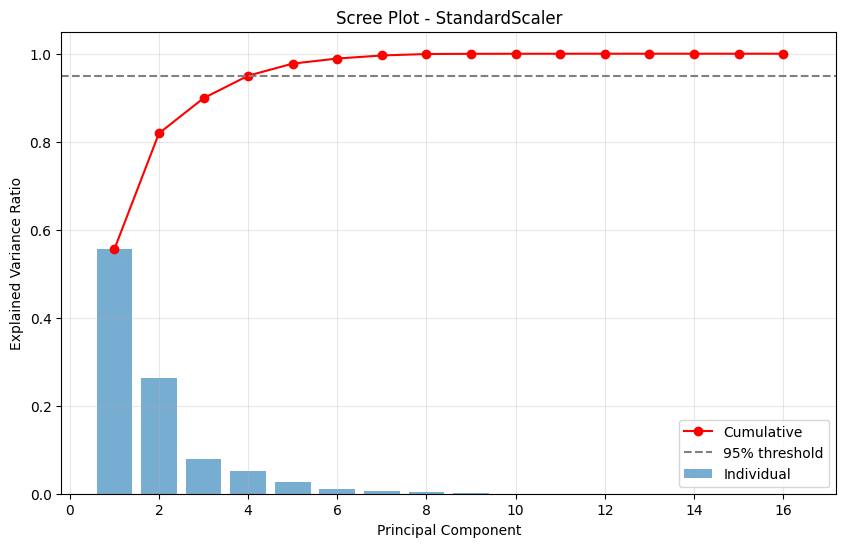

In [68]:
plt.figure(figsize=(10, 6))                             # Size
plt.bar(range(1, len(explained_variance_robust)+1), explained_variance_standard, alpha=0.6, label='Individual') # Setting bar
plt.plot(range(1, len(cumulative_variance_robust)+1), cumulative_variance_standard, marker='o', color='red', label='Cumulative') # Setting line
plt.axhline(y = 0.95, color = 'gray', linestyle='--', label = '95% threshold')
plt.xlabel('Principal Component')                       # X label title
plt.ylabel('Explained Variance Ratio')                  # y label title
plt.title('Scree Plot - StandardScaler')                # title
plt.legend()                                            # Add legend
plt.grid(axis = 'both', alpha = 0.3)                    # Add grid to improve the visualization
plt.show()                                              # display the plot

#### Standard Scaler Conclusion
From this graph, it can be seen that with 4 components, 95% of explained variance is reached, with minimal gains for each additional component from that point on.

It is worth noting that keeping these components with low real information introduces noise that could harm the model during the clustering stage.

> This analysis concludes that 4 is the ideal number of components, achieving the best performance without introducing redundancy or noise.

In [69]:
# Final PCA with 4 components - RobustScaler
pca_robust_final = PCA(n_components=4)
df_q3_pca_robust = pca_robust_final.fit_transform(df_q3_robust)

# Final PCA with 4 components - StandardScaler
pca_standard_final = PCA(n_components=4)
df_q3_pca_standard = pca_standard_final.fit_transform(df_q3_standard)

In [70]:
# Check if the number of features are reduced
df_q3_pca_robust.shape, df_q3_pca_standard.shape

((13543, 4), (13543, 4))

## K Means Clustering

### Robust

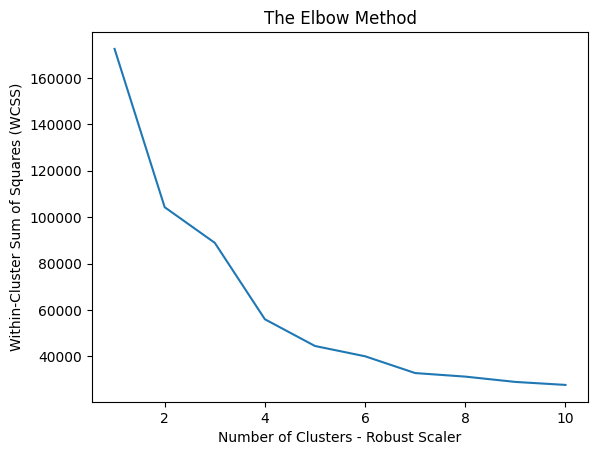

In [71]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state=42)
    kmeans.fit(df_q3_pca_robust)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters - Robust Scaler')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()

> The graph shows a sharp decline up to K=3, continuing to drop until K=5, but from that point on it becomes noticeably flatter. This indicates that, based on the Elbow Method, K=5 would be the ideal number of clusters.

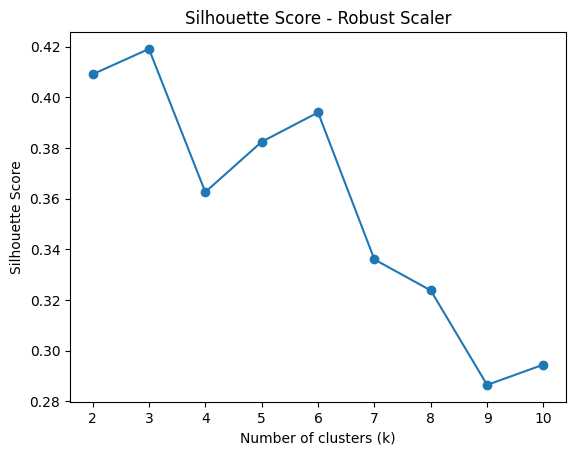

In [72]:
from sklearn.metrics import silhouette_score


sil_scores = []

for k in range(2, 11):
    labels = KMeans(n_clusters = k, random_state = 42, n_init = 10).fit_predict(df_q3_pca_robust)
    sil_scores.append(silhouette_score(df_q3_pca_robust, labels))

plt.figure()
plt.plot(range(2, 11), sil_scores, marker = 'o')
plt.title("Silhouette Score - Robust Scaler")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

> Using the Silhouette Score, K=3 achieved the highest score (0.42), while K=7 obtained a score of 0.34. This is worth highlighting, given that the dataset contains 7 real bean types.

> The difference between K=3 and K=7 can be explained by the fact that some bean types present very similar characteristics to one another, to the point of not forming seven geometrically distinct groups.

### Standard

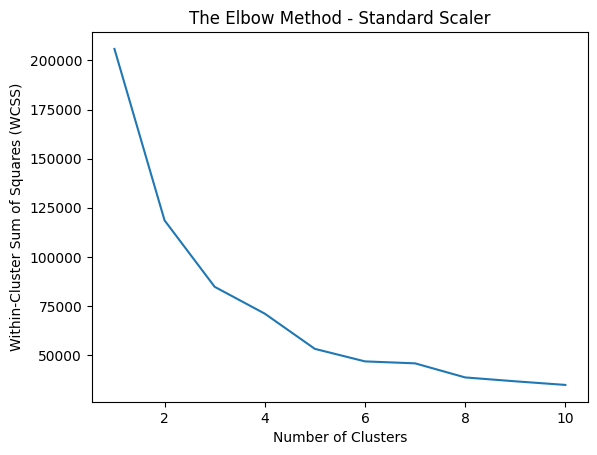

In [73]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state=42)
    kmeans.fit(df_q3_pca_standard)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method - Standard Scaler')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()

> The graph shows a sharp decline up to K=3, continuing to drop until K=5, but from that point on it becomes noticeably flatter. This indicates that, based on the Elbow Method, K=5 would also be the ideal number of clusters for the StandardScaler.

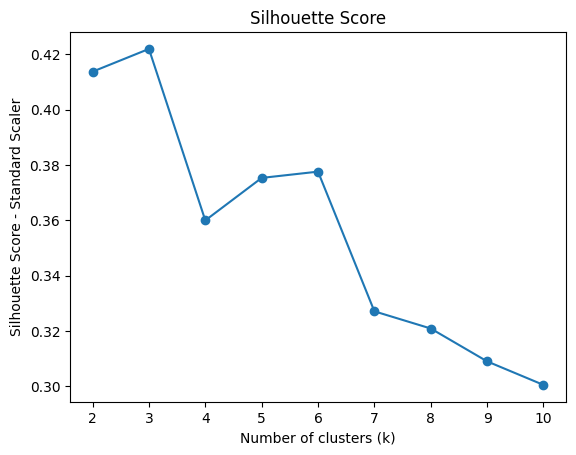

In [74]:
from sklearn.metrics import silhouette_score


sil_scores = []

for k in range(2, 11):
    labels = KMeans(n_clusters = k, random_state = 42, n_init = 10).fit_predict(df_q3_pca_standard)
    sil_scores.append(silhouette_score(df_q3_pca_standard, labels))

plt.figure()
plt.plot(range(2, 11), sil_scores, marker = 'o')
plt.title("Silhouette Score")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score - Standard Scaler")
plt.show()

> Using the StandardScaler, a very similar pattern to the one observed with RobustScaler was found. The Silhouette Score shows K=3 achieving the highest score (0.42), while K=7 obtained a score of 0.33. This is worth highlighting, given that the dataset contains 7 real bean types.

> The difference between K=3 and K=7 can be explained by the fact that some bean types present very similar characteristics to one another, to the point of not forming seven geometrically distinct groups.

### K-Means Final 
Two methods were used to define which value of K to use in the model: the **Elbow Method** suggested 5, and the **Silhouette Score** suggested 3. The result was the same using the 2 different scaling methods — **RobustScaler**, justified by the outliers, and **StandardScaler**, chosen for being the more common method and for assuming that the outliers are useful for capturing the difference between classes.

However, there are 7 different classes in the dataset, and considering that there was no unanimity between the values suggested by the two methods, and that the main goal is to capture these 7 classes, K = 7 will be used.

### Apply K-Means

In [75]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# K-Means final - RobustScaler
kmeans_robust_final = KMeans(n_clusters=7, init='k-means++', n_init=10, random_state=42)
labels_robust = kmeans_robust_final.fit_predict(df_q3_pca_robust)
silhouette_robust_final = silhouette_score(df_q3_pca_robust, labels_robust)

# K-Means final - StandardScaler
kmeans_standard_final = KMeans(n_clusters=7, init='k-means++', n_init=10, random_state=42)
labels_standard = kmeans_standard_final.fit_predict(df_q3_pca_standard)
silhouette_standard_final = silhouette_score(df_q3_pca_standard, labels_standard)

print(f"RobustScaler   | Silhouette Score (K=7): {silhouette_robust_final:.4f}")
print(f"StandardScaler | Silhouette Score (K=7): {silhouette_standard_final:.4f}")

RobustScaler   | Silhouette Score (K=7): 0.3360
StandardScaler | Silhouette Score (K=7): 0.3271


#### K-Means Scaling Method

As identified, using RobustScaler results in a slight performance difference compared to StandardScaler (0.3360 versus 0.3271). This is justified by the fact that preserving the outliers, in practice, also preserves the differences between each class, enabling a better separation into clusters. Therefore, only RobustScaler will be used from this point forward.

### Visualization

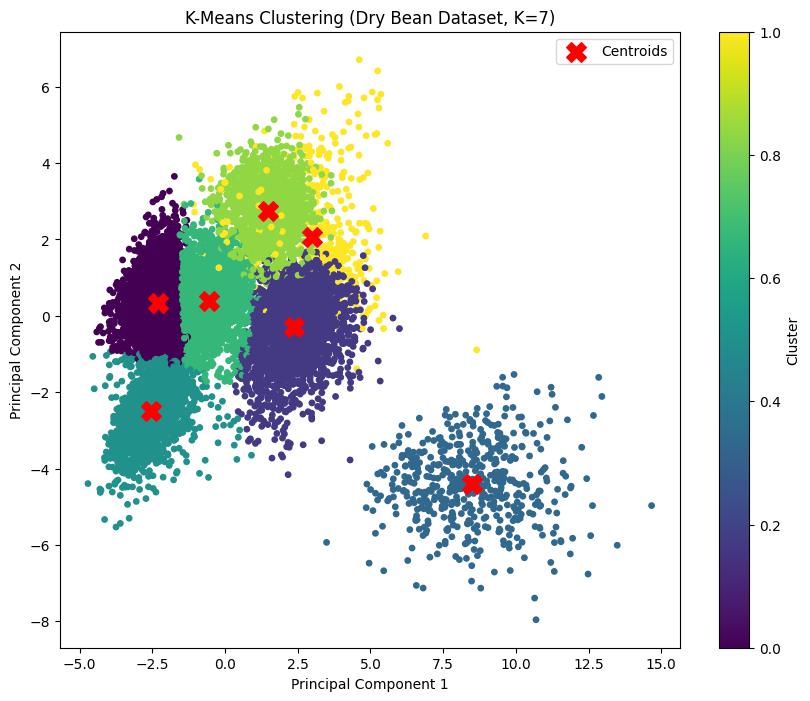

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Colored automatically by cluster label
plt.scatter(df_q3_pca_robust[:, 0], df_q3_pca_robust[:, 1], 
            c=labels_robust, cmap='viridis', s=15)

# Plot centroids
centroids = kmeans_robust_final.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], 
            marker='X', s=200, color='red', label='Centroids')

plt.title('K-Means Clustering (Dry Bean Dataset, K=7)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.legend()
plt.show()

> Although K=7 is not the value with the best Silhouette Score, it can be observed that the groups were clustered in a coherent way, even though some clusters are quite close to one another. It is worth noting that the clusters represented by the green and yellow colors, in particular, show overlap in some regions, graphically illustrating the similarity in characteristics between these bean types.

In [77]:
# Calculate Adjusted Rand Score
from sklearn.metrics import adjusted_rand_score

ari_robust = adjusted_rand_score(df_q3['Class'], labels_robust)
print(f"Adjusted Rand Index: {ari_robust:.4f}")

Adjusted Rand Index: 0.6807


#### Adjusted Rand Index Explanation

One way to validate the observation that the groups were clustered in a coherent way is by analyzing the ARI (Adjusted Rand Index) result. A value of 0.6807 was obtained, which indicates a good result — the ideal value would be 1.

However, as already expected, K=3 achieved the highest Silhouette Score, not K=7. Still, the fact that there are 7 real classes in the dataset made using K=7 more meaningful for this validation step.

In practice, this result indicates that the clustering captured the structure of the bean types well and that, despite not being perfect, there was a good agreement between the clusters formed and the real classes.

## Comparison: with PCA vs. without PCA

Before presenting the final comparison, it is useful to recall the previously obtained values, avoiding the need to scroll back through the notebook:

- **Silhouette Score with PCA (4 components, RobustScaler)**: 0.3360
- **Adjusted Rand Index with PCA**: 0.6807

The following step evaluates whether applying PCA actually improved clustering performance, by running K-Means (K=7) directly on the scaled data, without dimensionality reduction.

In [78]:
kmeans_no_pca = KMeans(n_clusters=7, init='k-means++', n_init=10, random_state=42)
labels_no_pca = kmeans_no_pca.fit_predict(df_q3_robust)

silhouette_no_pca = silhouette_score(df_q3_robust, labels_no_pca)

print(f"Silhouette Score WITH PCA (4 componentes): {silhouette_robust_final:.4f}")
print(f"Silhouette Score WITHOUT PCA (16 features originais): {silhouette_no_pca:.4f}")

Silhouette Score WITH PCA (4 componentes): 0.3360
Silhouette Score WITHOUT PCA (16 features originais): 0.3152


In [79]:
ari_no_pca = adjusted_rand_score(df_q3['Class'], labels_no_pca)
print(f"Adjusted Rand Index SEM PCA: {ari_no_pca:.4f}")

Adjusted Rand Index SEM PCA: 0.6773


| Metric | With PCA (4 components) | Without PCA (16 features) |
|---|---|---|
| Silhouette Score | 0.3360 | 0.3152 |
| Adjusted Rand Index (ARI) | 0.6807 | 0.6773 |

A discrete improvement is observed in the metrics. It becomes more noticeable when comparing the Silhouette Score values, since, due to the reduction from 16 features to 4, it is expected that having more compact information with lower dimensionality would improve the model's performance, considering that the clustering algorithm can trace distances more easily.

When comparing the ARI metric, however, the difference is much more subtle, since, despite the dimensionality reduction, all the information necessary to group the classes was already present in the original dataset. PCA does not add much in this regard, only working with more organized and compact data.

## Conclusion

In this question, **PCA** was applied with the goal of reducing the dimensionality of the dataset, which contained 16 features with many redundancies among them. Through PCA, these features were reduced to **4 components**, retaining **95%** of the original variance. With this reduction, **K-Means** was applied to group the beans into classes, considering the geometric characteristics provided by the dataset.

Given the importance of scaling, 2 methods were used: **RobustScaler**, considering its greater robustness in dealing with outliers, and **StandardScaler**, understanding that the outliers are crucial information for this clustering task, in addition to being the more commonly used scaler. **RobustScaler** achieved better performance (Silhouette Score = **0.3360** versus **0.3271** for StandardScaler), and was therefore chosen for the following steps.

In the search for the value of K, the Elbow Method suggested **5**, while the Silhouette Score suggested **3**. However, **K = 7** was defined, considering that there are 7 bean classes. This logic was validated by the Adjusted Rand Index (**ARI = 0.6807**), a result that confirmed good agreement between the clusters and the real classes.

A comparison of this model's performance on the dataset **with and without PCA** was also carried out, and the results obtained were: Silhouette Score = **0.3360 vs 0.3152**; ARI = **0.6807 vs 0.6773**. Despite a slight difference, it is more noticeable in the Silhouette Score — this is where the reduction really makes a difference: after reducing dimensionality from 16 to 4, redundancy is reduced and it becomes easier for the model to calculate distance, which is why this metric shows a more noticeable difference than the other one. Similarly, since the dataset already contained all the necessary information for grouping from the start, PCA **did not create anything new** during the process, it only organized what already existed in a more compact way.

As a limitation, it is worth noting that it was not possible to achieve a **perfect separation** of the bean types, suggesting that, despite being different classes, they share many geometric similarities, which makes a fully precise separation difficult.

# QUESTION 4

In [80]:
# Read and display the dataset
df_q4 = pd.read_csv("question4/energydata.csv")

df_q4.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


## Initial EDA

In [81]:
# View features informations
df_q4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

### Dataset Attributes (29 total: 28 features, 1 target)

| Attribute | Description |
|---|---|
| `date` | Date and time of the observation (year-month-day hour:minute:second) |
| `Appliances` | Energy use of appliances, in Wh (**target**) |
| `lights` | Energy use of light fixtures in the house, in Wh |
| `T1` | Temperature in kitchen area, in Celsius |
| `RH_1` | Humidity in kitchen area, in % |
| `T2` | Temperature in living room area, in Celsius |
| `RH_2` | Humidity in living room area, in % |
| `T3` | Temperature in laundry room area, in Celsius |
| `RH_3` | Humidity in laundry room area, in % |
| `T4` | Temperature in office room, in Celsius |
| `RH_4` | Humidity in office room, in % |
| `T5` | Temperature in bathroom, in Celsius |
| `RH_5` | Humidity in bathroom, in % |
| `T6` | Temperature outside the building (north side), in Celsius |
| `RH_6` | Humidity outside the building (north side), in % |
| `T7` | Temperature in ironing room, in Celsius |
| `RH_7` | Humidity in ironing room, in % |
| `T8` | Temperature in teenager room 2, in Celsius |
| `RH_8` | Humidity in teenager room 2, in % |
| `T9` | Temperature in parents room, in Celsius |
| `RH_9` | Humidity in parents room, in % |
| `T_out` | Temperature outside (from Chièvres weather station), in Celsius |
| `Press_mm_hg` | Pressure (from Chièvres weather station), in mm Hg |
| `RH_out` | Humidity outside (from Chièvres weather station), in % |
| `Windspeed` | Wind speed (from Chièvres weather station), in m/s |
| `Visibility` | Visibility (from Chièvres weather station), in km |
| `Tdewpoint` | Dew point temperature (from Chièvres weather station), in °C |
| `rv1` | Random variable 1, non-dimensional |
| `rv2` | Random variable 2, non-dimensional |

In [82]:
# Converting object feature to date
df_q4['date'] = pd.to_datetime(df_q4['date'])
df_q4 = df_q4.set_index('date')

In [83]:
# Check if it worked
df_q4.index

DatetimeIndex(['2016-01-11 17:00:00', '2016-01-11 17:10:00',
               '2016-01-11 17:20:00', '2016-01-11 17:30:00',
               '2016-01-11 17:40:00', '2016-01-11 17:50:00',
               '2016-01-11 18:00:00', '2016-01-11 18:10:00',
               '2016-01-11 18:20:00', '2016-01-11 18:30:00',
               ...
               '2016-05-27 16:30:00', '2016-05-27 16:40:00',
               '2016-05-27 16:50:00', '2016-05-27 17:00:00',
               '2016-05-27 17:10:00', '2016-05-27 17:20:00',
               '2016-05-27 17:30:00', '2016-05-27 17:40:00',
               '2016-05-27 17:50:00', '2016-05-27 18:00:00'],
              dtype='datetime64[ns]', name='date', length=19735, freq=None)

Considering the large number of features, and that not all of them are relevant — at least at this point —, the statistical summary will be generated only for the `Appliances` column, which is the most important one for this analysis.

In [84]:
# Appliances Statistical summary 
df_q4["Appliances"].describe()

count    19735.000000
mean        97.694958
std        102.524891
min         10.000000
25%         50.000000
50%         60.000000
75%        100.000000
max       1080.000000
Name: Appliances, dtype: float64

> Based on this summary, a high variance in the values can be observed, given that the standard deviation (102.52) is even higher than the mean itself (97.69). The difference between the mean (97.69) and the median (60) also suggests the presence of outliers, which is evidenced by the fact that the maximum value is 1080, while the minimum is 10. This is an expected pattern, considering that the data was collected at different times of the day, and energy consumption tends to vary significantly depending on the time.

In [85]:
# Check null values
df_q4.isnull().sum()

Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [86]:
# Check duplicates
df_q4.duplicated().sum()

np.int64(0)

> There are no null or duplicate values. The 'url' column was also checked, as it serves as a unique identifier, yet no duplicates were found.

In [87]:
# Check features names
df_q4.columns

Index(['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4',
       'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9',
       'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility',
       'Tdewpoint', 'rv1', 'rv2'],
      dtype='object')

In [88]:
# Check for temporal regularity
time_diffs = df_q4.index.to_series().diff()
time_diffs.value_counts()

date
0 days 00:10:00    19734
Name: count, dtype: int64

## Stationary or not?

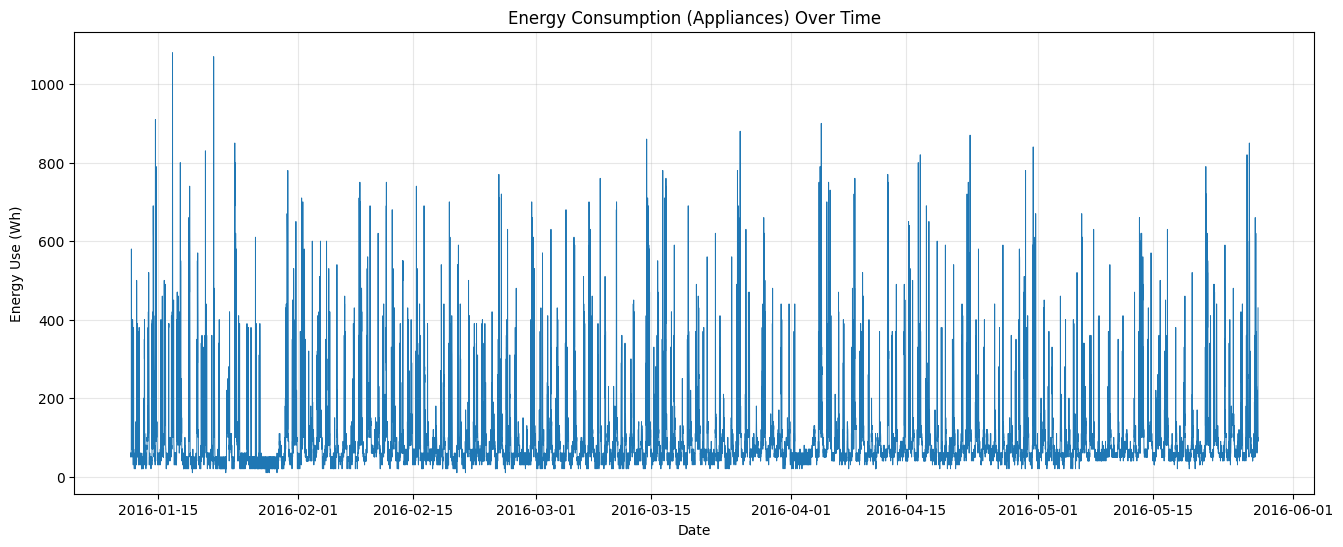

In [89]:
# Plot the full time series of energy consumption
plt.figure(figsize=(16, 6))
plt.plot(df_q4.index, df_q4['Appliances'], linewidth=0.7)
plt.title('Energy Consumption (Appliances) Over Time')
plt.xlabel('Date')
plt.ylabel('Energy Use (Wh)')
plt.grid(alpha=0.3)
plt.show()

> The graph suggests that, despite the differences in values, the pattern remains constant over time. However, due to the large number of samples, the visualization alone is not sufficient to confirm this conclusion, which is why additional tests will be carried out.

In [90]:
##Ho: It is non stationary
##H1: It is stationary

def adfuller_test(Appliances):
    result=adfuller(Appliances)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

> In order to define which variation of ARIMA will be used, it is important to understand whether the data is stationary or not. 

In [91]:
# Run adfuller function
from statsmodels.tsa.stattools import adfuller

adfuller_test(df_q4['Appliances'])

ADF Test Statistic : -21.616378198036106
p-value : 0.0
#Lags Used : 11
Number of Observations Used : 19723
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


> The result shown by the function above means that the data is stationary. In practice, this means it presents a pattern that repeats itself. Even though, when thinking about electricity consumption, these numbers tend to vary, this variation occurs within already known ranges, without major shifts in level over time.

> Given that the series is stationary, differencing is not required before modeling.

## ACF and PACF Analysis

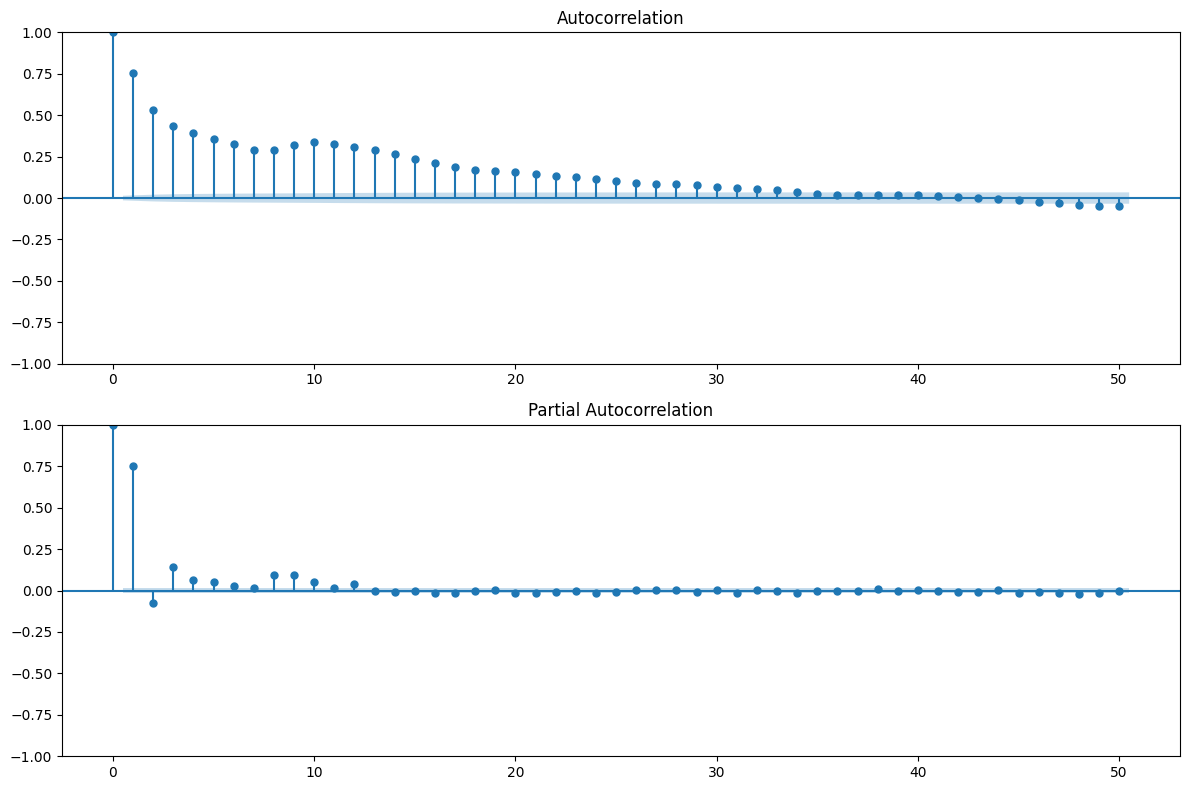

In [92]:
import statsmodels.api as sm

fig = plt.figure(figsize=(12, 8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df_q4['Appliances'], lags=50, ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df_q4['Appliances'], lags=50, ax=ax2)
plt.tight_layout()
plt.show()

#### Final Thoughts on Autocorrelation and Partial Autocorrelation

* Identification of an AR model is often best done with the PACF.
    * For an AR model, the theoretical PACF "shuts off" past the order of the model. The phrase "shuts off" means that in theory the partial autocorrelations are equal to 0 beyond that point. Put another way, the number of non-zero partial autocorrelations gives the order of the AR model. By the "order of the model" we mean the most extreme lag of x that is used as a predictor.

The PACF is used to identify an AR model. Looking at the plot, there are no abrupt drops in the ACF — the values decrease gradually, starting at approximately 0.75 at lag 1, and following a pattern of light, continuous reduction across the remaining lags.

The PACF, on the other hand, shows a different behavior: a sharp drop is clearly visible between the first lag (~1.0) and the third lag (~-0.1).

* Identification of an MA model is often best done with the ACF rather than the PACF.
    * For an MA model, the theoretical PACF does not shut off, but instead tapers toward 0 in some manner. A clearer pattern for an MA model is in the ACF. The ACF will have non-zero autocorrelations only at lags involved in the model.

    p, d, q
    p — AR model lags
    d — differencing
    q — MA lags

Applying the theory above to what was observed: since the PACF shows an abrupt cutoff while the ACF decays gradually, this pattern indicates an **AR-dominated series**, suggesting an initial model such as **ARIMA(1, 0, 0)** or **ARIMA(2, 0, 0)** (with d = 0, since the series was already confirmed to be stationary).

## Seasonal Decomposition (Additive vs. Multiplicative)

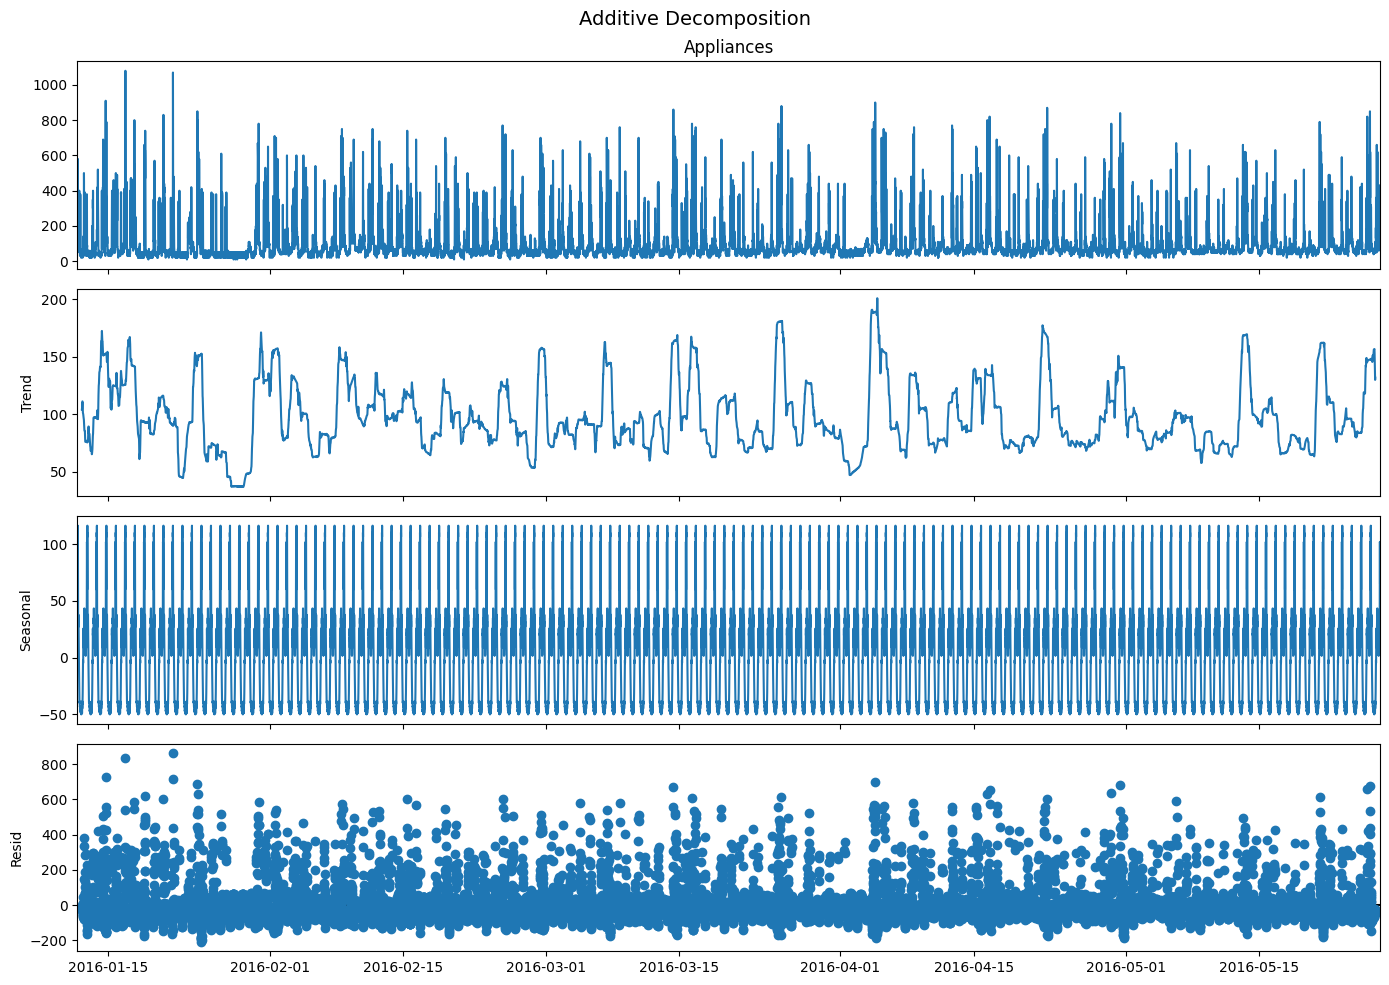

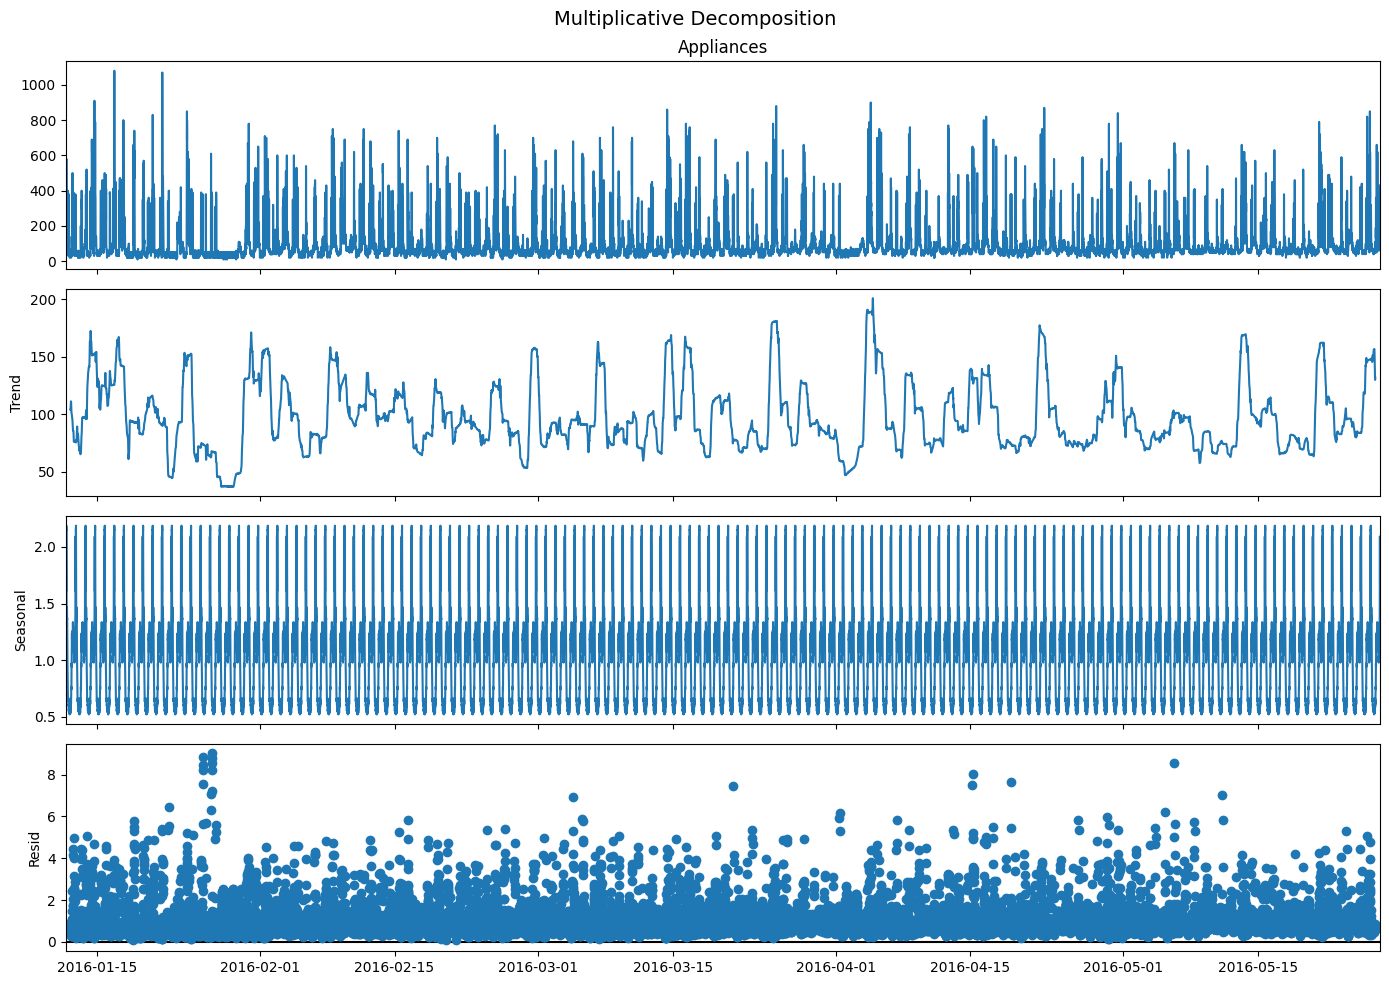

In [93]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Additive decomposition
decomposition_add = seasonal_decompose(df_q4['Appliances'], model='additive', period=144)

# Multiplicative decomposition
decomposition_mult = seasonal_decompose(df_q4['Appliances'], model='multiplicative', period=144)

fig1 = decomposition_add.plot()
fig1.suptitle('Additive Decomposition', fontsize=14)
fig1.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

fig2 = decomposition_mult.plot()
fig2.suptitle('Multiplicative Decomposition', fontsize=14)
fig2.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

#### Seasonal Decomposition Decision
Comparing the two decompositions, it can be seen that the trend components are practically identical between both models, since both use the same moving average calculation. The seasonal component shows the same repeating pattern in both cases, differing only in scale (absolute values in the additive model, proportional factors in the multiplicative one).

Although not identical, the pattern is very similar in terms of the residuals. This indicates that choosing either decomposition would not be a mistake. However, due to the fact that the additive decomposition is linear, the result becomes easier to interpret, which is why it was the one chosen.

## Train & Test

In [94]:
# Split into train & test
train_size = int(len(df_q4) * 0.8)
train = df_q4['Appliances'].iloc[:train_size]
test = df_q4['Appliances'].iloc[train_size:]

print(train.shape, test.shape)

(15788,) (3947,)


## ARIMA TRAIN

In [95]:
from statsmodels.tsa.arima.model import ARIMA

# Train ARIMA model
model_arima = ARIMA(train, order=(1, 0, 0))
model_arima_fit = model_arima.fit()

# Model summary
print(model_arima_fit.summary())

C:\Users\lucas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\lucas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\lucas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Appliances   No. Observations:                15788
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -89194.473
Date:                Sat, 08 Aug 2026   AIC                         178394.945
Time:                        21:09:23   BIC                         178417.946
Sample:                    01-11-2016   HQIC                        178402.557
                         - 04-30-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         98.0245      4.268     22.965      0.000      89.659     106.390
ar.L1          0.7569      0.004    214.905      0.000       0.750       0.764
sigma2      4727.4683     22.548    209.661      0.0

In [96]:
from statsmodels.tsa.arima.model import ARIMA

# Train ARIMA model with different p
model_arima = ARIMA(train, order=(2, 0, 0))
model_arima_fit = model_arima.fit()

# Model summary
print(model_arima_fit.summary())

C:\Users\lucas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\lucas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
C:\Users\lucas\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Appliances   No. Observations:                15788
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -89147.472
Date:                Sat, 08 Aug 2026   AIC                         178302.943
Time:                        21:09:32   BIC                         178333.611
Sample:                    01-11-2016   HQIC                        178313.093
                         - 04-30-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         98.0244      3.976     24.654      0.000      90.231     105.817
ar.L1          0.8152      0.004    189.378      0.000       0.807       0.824
ar.L2         -0.0770      0.004    -17.810      0.0

### ARIMA Model Comparison

| Metric | ARIMA(1,0,0) | ARIMA(2,0,0) |
|---|---|---|
| AIC | 178,394.95 | **178,302.94** |
| BIC | 178,417.95 | **178,333.61** |
| Ljung-Box Prob(Q) | 0.00 | **0.19** |
| ar.L1 (coef) | 0.7569 | 0.8152 |
| ar.L2 (coef) | — | -0.0770 |
| const (coef) | 98.02 | 98.02 |


**AIC** — The lower, the better the model. It evaluates how well the model fits the data, but also takes into account the number of parameters, thereby avoiding overfitting.

**BIC** — Similar to AIC, however, it tends to penalize models with many parameters more heavily. Ideally, the lower, the better.

**Ljung-Box** — Useful for checking whether the remaining residuals are independent, meaning there is no leftover pattern in them (the model has already captured the existing patterns in the series). Good results are obtained when the p-value is greater than the significance level of 0.05.

**ar.L1 (coef)** — Represents the weight that the 10-minute lag has in determining the next value. Since the data collection interval is 10 minutes, this means it is possible to identify how much the value collected 10 minutes ago influences the prediction of the current value.

**ar.L2 (coef)** — A similar idea to the previous one, however, this one analyzes the weight of 20 minutes ago (2 collections).

**const (coef)** — Represents the average value around which the series oscillates.

In [97]:
# Forecast on the test period using the best ARIMA model (2,0,0)
forecast_arima = model_arima_fit.forecast(steps=len(test))

In [98]:
# Check for zero values in test (to avoid division by zero in MAPE)
(test == 0).sum()

np.int64(0)

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate error metrics
mae_arima = mean_absolute_error(test, forecast_arima)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
mape_arima = np.mean(np.abs((test - forecast_arima) / test)) * 100

print(f"MAE: {mae_arima:.2f}")
print(f"RMSE: {rmse_arima:.2f}")
print(f"MAPE: {mape_arima:.2f}%")

MAE: 52.54
RMSE: 90.68
MAPE: 59.89%


#### ARIMA Error Metrics Conclusion
**MAE = 52.53** — Average error, an easy-to-interpret metric. In this model, it means that when an error occurs, it tends to be around 52.53 Wh above or below the actual value. Looking at the statistical summary, this value can be considered high, given that `Appliances` had a mean of ~97.69 Wh and a median of ~60 Wh — meaning the average error is almost as large as the series' own median.

**RMSE = 90.66** — By penalizing large errors more heavily, it shows a value much higher than the MAE. This makes sense when looking at the describe values, such as the maximum of 1080 (while the median is only 60) — extreme values like this tend to considerably increase this metric.

**MAPE = 59.88%** — Knowing that there are no zero values in the series (which could distort the calculation), the MAPE result is not good, considering that an error of nearly 60% is greater than half of the value being predicted.

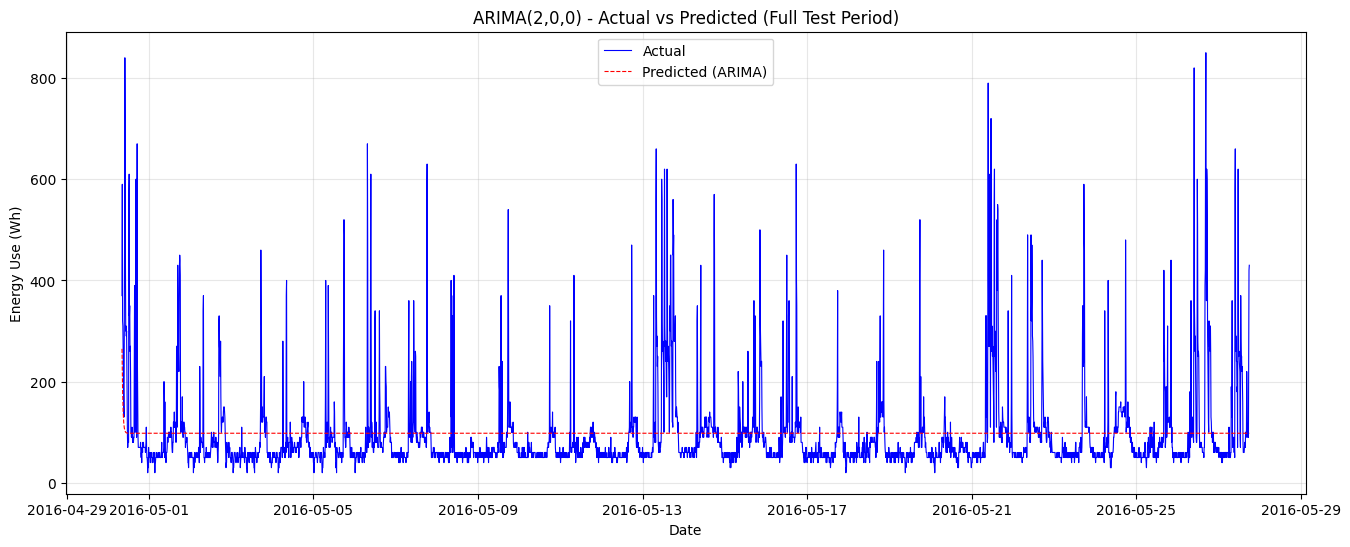

In [100]:
plt.figure(figsize=(16, 6))
plt.plot(test.index, test.values, label='Actual', color='blue', linewidth=0.8)
plt.plot(test.index, forecast_arima.values, label='Predicted (ARIMA)', color='red', linewidth=0.8, linestyle='--')
plt.title('ARIMA(2,0,0) - Actual vs Predicted (Full Test Period)')
plt.xlabel('Date')
plt.ylabel('Energy Use (Wh)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

> This graph clearly illustrates the error metric values presented earlier. It is evident that the model fails to capture the peaks — the predicted values are represented on the graph almost as a straight line.

> It is worth noting that ARIMA does not perform well when facing sudden peaks, as shown in this graph. This is also related to the fact that this model is sensitive to outliers, a characteristic that had already been identified throughout the notebook (both in the graphs and in the

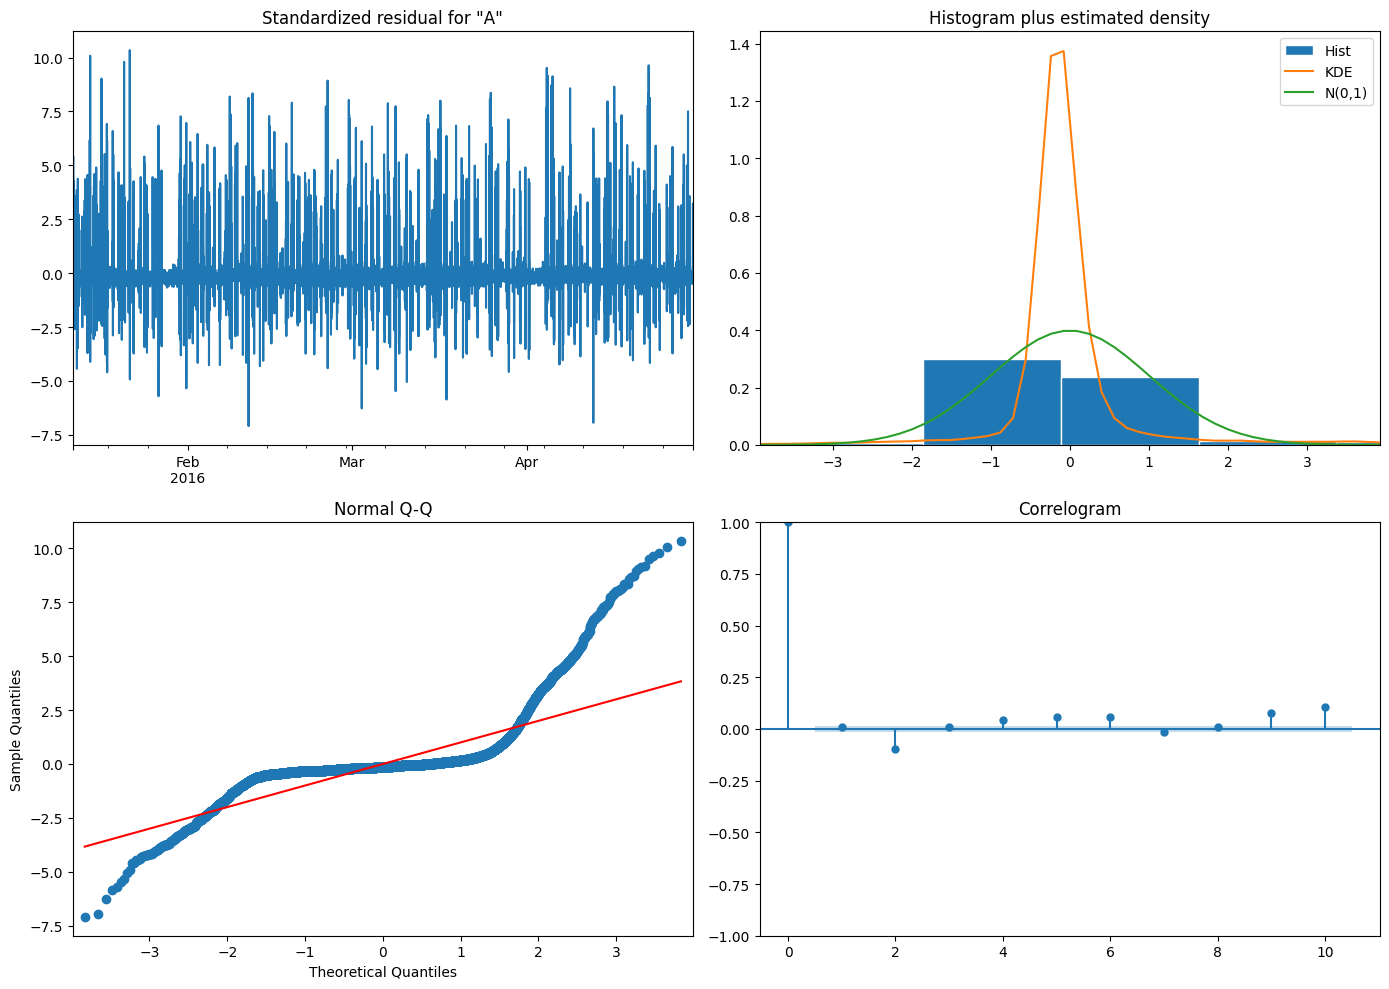

In [101]:
# Diagnostic
model_arima_fit.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

#### Residual Diagnostics

Based on these residual-related graphs, it is possible to make a diagnosis of the model.

**Graph 1: Standardized Residual**

There is no clear trend in the graph, which is good because it indicates that no temporal pattern was found in the residuals. However, there is also no constant variation: there are calmer periods and others that are more intense. A constant change in the dispersion of the data can be identified, a behavior known as **heteroscedasticity**.

**Graph 2: Histogram**

We can see the histogram (blue bars) and the orange line (KDE), with the information visualized in different ways. When the orange line is compared with the green line (normal distribution), the actual distribution of the residuals becomes visible. Ideally, it would have the same distribution as the green line; however, a longer tail can be noticed, with most of the data highly concentrated, forming this more **“funnel-shaped” pattern**.

**Graph 3: Normal Q-Q**

It can be noticed that, especially at the ends, the points move away from the red line, visually illustrating how the outliers (both positive and negative) are present and how this affects the model’s performance. From this graph, it is possible to understand why the model made a **straight-line prediction**, failing to capture peaks and extreme values.

**Graph 4: Correlogram**

It shows the autocorrelation of the residuals. The expected behavior is for them to remain within the confidence interval, indicating that the patterns have already been identified by the model. It can therefore be noted that the graph is clean, with **no significant remaining autocorrelation**.

## SARIMA TRAIN

In [102]:
# Change the frequency from 10 min to 1 hour
train_hourly = train.resample("1h").mean()

In [103]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Train SARIMA model (p,d,q)(P,D,Q,s)
model_sarima = SARIMAX(train_hourly, order=(2, 0, 0), seasonal_order=(1, 0, 1, 24))
model_sarima_fit = model_sarima.fit()

# Model summary
print(model_sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                           Appliances   No. Observations:                 2632
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 24)   Log Likelihood              -14649.287
Date:                              Sat, 08 Aug 2026   AIC                          29308.573
Time:                                      21:11:00   BIC                          29337.951
Sample:                                  01-11-2016   HQIC                         29319.211
                                       - 04-30-2016                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3795      0.013     29.881      0.000       0.355       0.404
ar.L2          0.23

### SARIMA Results

Due to memory limitations when processing the daily seasonality (**s=144**) on data collected every 10 minutes, it was necessary to aggregate these samples into hours, resulting in **s=24**, representing the 24 hours equivalent to 1 day. For this reason, a direct comparison with the ARIMA model is not recommended, given that ARIMA used **15,788** samples, while SARIMA used only **2,632**. However, the following error metrics are important and should be considered, since both are on the same unit scale (Wh) — one should only avoid directly comparing metrics such as AIC and BIC between the models, given the significant difference in sample size.

The coefficient value **ar.S.L24 = 0.9981** is very high, close to 1, indicating strong seasonal dependence — a result that makes complete sense, since the frequency was changed to 24 hours, equivalent to 1 day.

The **Ljung-Box test (Prob(Q) = 0.71)** also confirms that there is no significant autocorrelation in the residuals, as the value is much higher than 0.05, meaning the model captured the temporal patterns well. However, as already seen previously and to be further investigated, the issue of **outliers** remains a strong limitation of the model: analyzing the Jarque-Bera metrics (**Skew: 2.01** and **Kurtosis: 11.39**), this limitation becomes clear.

In [104]:
# Forecast on the test period
forecast_sarima = model_sarima_fit.forecast(steps=len(test))

In [105]:
# Calculate error metrics
mae_sarima = mean_absolute_error(test, forecast_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))
mape_sarima = np.mean(np.abs((test - forecast_sarima) / test)) * 100

print(f"MAE: {mae_sarima:.2f}")
print(f"RMSE: {rmse_sarima:.2f}")
print(f"MAPE: {mape_sarima:.2f}%")

MAE: 54.46
RMSE: 96.34
MAPE: 40.17%


#### SARIMA Error Metrics Conclusion

**MAE = 54.46** — The model's predictions differ from the actual values by approximately 54.46 Wh, on average. This result is slightly higher than the ARIMA model's MAE of 52.53 Wh.

**RMSE = 96.34** — This value is higher than the MAE and also higher than the ARIMA model's RMSE of 90.68 Wh. Since this metric penalizes larger errors more heavily, this result suggests that SARIMA still has difficulties with extreme errors.

**MAPE = 40.17%** — This represents an improvement compared with the MAPE of 59.88% obtained by the ARIMA model. However, this value is still high, indicating that the model continues to have difficulties predicting the records accurately.

Overall, the SARIMA model showed a significant improvement in percentage-based performance when compared with ARIMA. Nevertheless, it presented larger absolute errors and had difficulties capturing the peaks and extreme values in the series.

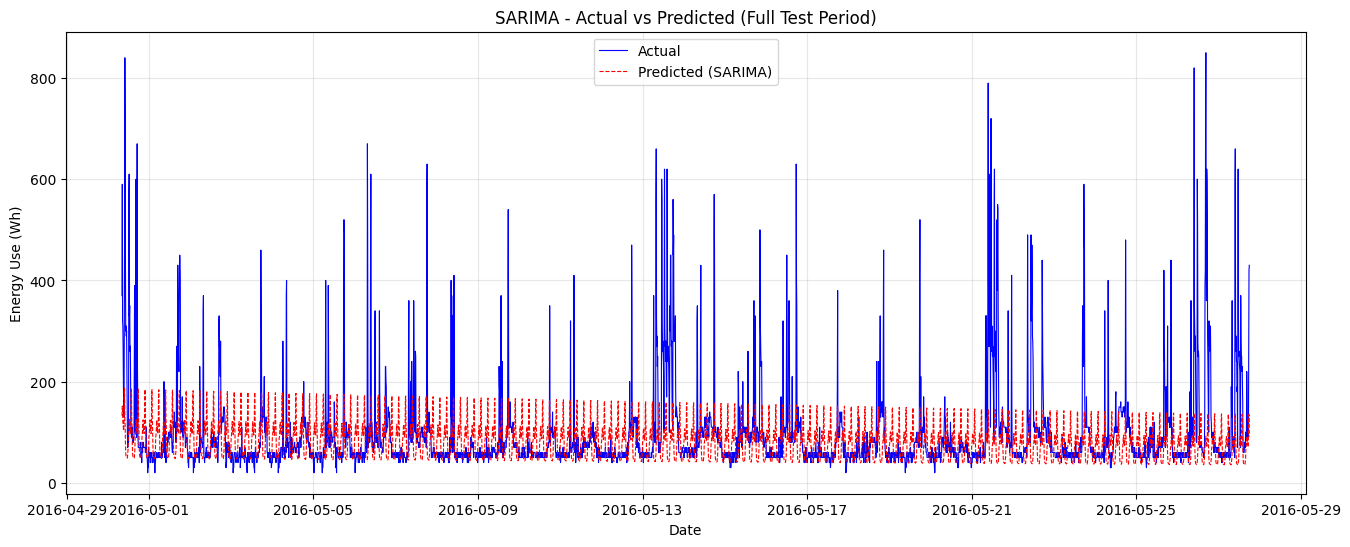

In [106]:
plt.figure(figsize=(16, 6))
plt.plot(test.index, test.values, label='Actual', color='blue', linewidth=0.8)
plt.plot(test.index, forecast_sarima.values, label='Predicted (SARIMA)', color='red', linewidth=0.8, linestyle='--')
plt.title('SARIMA - Actual vs Predicted (Full Test Period)')
plt.xlabel('Date')
plt.ylabel('Energy Use (Wh)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

> Observing this graph, it can be seen that, unlike the ARIMA model, the predictions tend to follow a larger portion of the actual observations more closely. This performance is even better during periods that do not show much variation.

> This illustrates in practice what was mentioned earlier: the model showed a significant improvement in performance. However, this behavior does not occur during the peaks, which confirms the impressions obtained from the error metrics.

> Therefore, despite the overall improvement, the model still presents limitations. These limitations will be analysed in greater depth in the final conclusion.

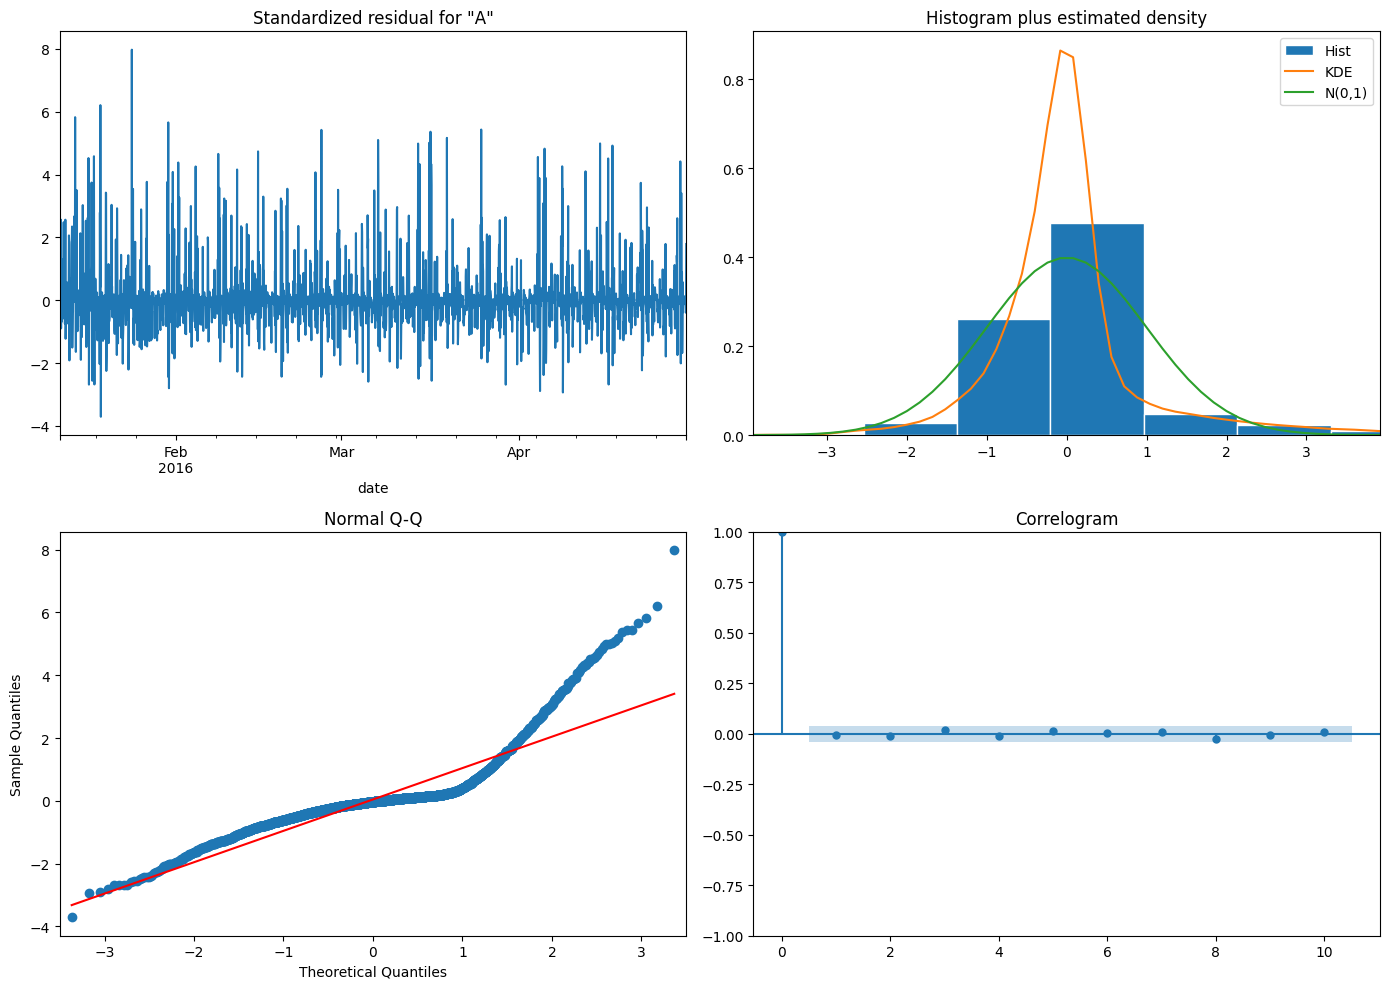

In [107]:
# Diagnostic
model_sarima_fit.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

#### Residual Diagnostics (SARIMA)

**Graph 1: Standardized Residual**

The pattern is similar to what was observed in ARIMA — no clear temporal trend, but still showing **heteroscedasticity** (periods of higher and lower intensity). It is worth noting, however, that the amplitude of the residuals decreased (ranging from approximately -4 to 8, versus -7.5 to 10 in ARIMA), suggesting slightly smaller errors.

**Graph 2: Histogram**

A difference in shape can be noticed: unlike ARIMA, this graph shows a more **bimodal** pattern, with a higher concentration of values near 0. Still, the distribution remains far from the normal curve (green), reinforcing that the residuals remain more concentrated than expected.

**Graph 3: Normal Q-Q**

The points still deviate from the red line at the extremes, indicating the presence of residual outliers — a behavior similar to that of the ARIMA model. However, the deviations are **less intense** compared to the ARIMA model, especially across most of the distribution.

**Graph 4: Correlogram**

As with ARIMA, the graph is clean, with no significant remaining autocorrelation. This result is reinforced by the Ljung-Box test, whose p-value (0.71) is even higher than the one obtained in ARIMA (0.19), indicating an **even better** fit of the residuals.


## Final Comparison: ARIMA vs. SARIMA

Comparing the two models isn't entirely straightforward, and some aspects deserve a closer look. Initially, SARIMA's **MAE** and **RMSE** are slightly higher than ARIMA's, which could suggest that ARIMA performed better. However, SARIMA's **MAPE** shows a very different value, considerably lower (**40.17%** versus **59.88%**). The explanation lies in how the data was prepared: SARIMA was trained on hourly-aggregated data, while ARIMA kept the original 10-minute granularity. Hourly aggregation naturally smooths out sharp peaks, which improves the percentage error, even though the absolute error remains similar. For this reason, comparing the two models' error metrics side by side should be done with caution; it is not a direct comparison between equivalent elements.

A more reliable way to assess the fit is the **Ljung-Box test**, since it evaluates the model's ability to capture the underlying patterns, regardless of the data's scale. Here, the difference is much clearer: SARIMA achieved **Prob(Q) = 0.71**, compared to just **0.19** for ARIMA. This aligns with what the seasonal coefficient already indicated: the inclusion of the seasonal term (**ar.S.L24 = 0.9981**) made a real difference in the model's ability to capture the series' recurring patterns.

Thus, although the results are not perfect, the overall picture points to **SARIMA as the more suitable model**, reinforcing that daily seasonality is genuinely important when trying to understand residential electricity consumption.

## Conclusion

In question 4, the **ARIMA** and **SARIMA** models were applied with the goal of forecasting energy consumption, based on a dataset that collected data in real time every 10 minutes. Through the **ADF** test, which returned a **p-value of 0**, it was confirmed that the series was stationary and did not require differencing. The **ACF** and **PACF** plots indicated autoregressive behavior, which was later trained using **ARIMA(2,0,0)** and, as a form of validation, was assessed through the **Ljung-Box** test.

However, based on the series decomposition, a clear and consistent seasonal pattern was identified, which led to applying the **SARIMA** model with a seasonal component of **24-hour period**. Due to memory limitations when processing seasonality on 10-minute interval data, it was necessary to aggregate the data by hour before training SARIMA — a methodological limitation that prevents a direct comparison of certain metrics (such as **AIC/BIC**) between the two models, although it does not invalidate the overall performance comparison.

Comparing the two models, **SARIMA demonstrated a better ability to capture the series' patterns**. This was confirmed by the Ljung-Box test (**Prob(Q) = 0.71** versus **0.19** for ARIMA) and by the strongly significant seasonal coefficient (**ar.S.L24 = 0.9981**). This confirms that **daily seasonality** is indeed a relevant component of residential energy consumption — being higher in the morning and evening, in cycles that repeat consistently throughout the analyzed period.

A few limitations are worth highlighting. Even with two models applied, **both struggled to capture extreme consumption peaks**, a limitation confirmed by the Jarque-Bera tests and the Q-Q plots, which showed residual distributions with heavier tails than expected. In addition, while the ARIMA model had its parameters compared across two configurations (**p=1** and **p=2**), SARIMA was trained using only a single seasonal configuration, due to the high computational cost of testing multiple combinations for this type of model.

As an opportunity for improvement: it would be worth testing SARIMA with other combinations of seasonal parameters, something that wasn't feasible here due to the computational cost involved. It would also be interesting to make use of the **temperature and humidity** variables that were already available in the original dataset but ended up not being used.

## References

- scikit-learn.org. (n.d.). sklearn.preprocessing.PolynomialFeatures — scikit-learn 0.23.2 documentation. [online] Available at: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html [Accessed 16 July 2026].

- scikit-learn developers (2019). sklearn.linear_model.LinearRegression — scikit-learn 0.22 documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html [Accessed 16 July 2026]. 

- scikit-learn (2018). 3.2.4.3.2. sklearn.ensemble.RandomForestRegressor — scikit-learn 0.20.3 documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html [Accessed 16 July 2026].

- Scikit-learn (2019). sklearn.model_selection.GridSearchCV — scikit-learn 0.22 Documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html [Accessed 16 July 2026].

- UCI Machine Learning Repository. (n.d.). [online] archive.ics.uci.edu. Available at: https://archive.ics.uci.edu/dataset/332/online+news+popularity [Accessed 20 July 2026].

- numpy.select — NumPy v1.21 Manual. (n.d.). [online] numpy.org. Available at: https://numpy.org/doc/stable/reference/generated/numpy.select.html [Accessed 20 July 2026].

- scipy.stats.skew — SciPy v1.7.1 Manual. (n.d.). [online] docs.scipy.org. Available at: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skew.html [Accessed 21 July 2026].

- scikit-learn (2014). LogisticRegression. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html [Accessed 21 July 2026].

- Scikit-Learn (2025). sklearn.ensemble.RandomForestClassifier — scikit-learn 0.20.3 Documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html [Accessed 21 July 2026].

- scikit-learn (2019). sklearn.neighbors.KNeighborsClassifier — scikit-learn 0.22.1 documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html [Accessed 21 July 2026].

- scikit-learn (2019). Confusion matrix — scikit-learn 0.22 documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html [Accessed 21 July 2026].

- UCI Machine Learning Repository. (n.d.). [online] archive.ics.uci.edu. Available at: https://archive.ics.uci.edu/dataset/602/dry+bean+dataset [Accessed 22 July 2026].

- scikit-learn (2009). sklearn.decomposition.PCA — scikit-learn 0.20.3 documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html [Accessed 24 July 2026].

- Scikit-learn (2019). sklearn.metrics.silhouette_score — scikit-learn 0.21.3 documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html [Accessed 28 July 2026].

- Iqbal, M. (2026) Week 11: K-Means Clustering [Jupyter notebook]. CCT College Dublin.

- Sabu, S. (2024). Rand Index (RI) vs. Adjusted Rand Index (ARI) in K-Means Clustering. [online] Medium. Available at: https://medium.com/@samson.sabu/rand-index-ri-vs-adjusted-rand-index-ari-in-k-means-clustering-06c364bdf1ef [Accessed 24 July 2026].

- sklearn.metrics.adjusted_rand_score — scikit-learn 0.23.1 documentation. (n.d.). [online] scikit-learn.org. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html [Accessed 24 July 2026].

- UCI Machine Learning Repository. (n.d.). [online] archive.ics.uci.edu. Available at: https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction [Accessed 26 July 2026].

- Ahmed, T. (2026) ARIMA_SARIMA [Jupyter notebook]. CCT College Dublin. [Accessed 28 July 2026].

- Acharya, S.K. (n.d.) Lecture 8: Different Types of Time Series Modelling. CCT College Dublin. [Accessed 28 July 2026].

- Acharya, S.K. (n.d.) Lecture 7: Introduction_To_Forecasting. CCT College Dublin. [Accessed 28 July 2026]. Introduction_To_Forecasting

- statsmodels.tsa.seasonal.seasonal_decompose — statsmodels. (n.d.). [online] www.statsmodels.org. Available at: https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.seasonal_decompose.html [Accessed 30 July. 2026].

- Brownlee, J. (2017). How to Decompose Time Series Data into Trend and Seasonality. [online] Machine Learning Mastery. Available at: https://machinelearningmastery.com/decompose-time-series-data-trend-seasonality/ [Accessed 30 July. 2026].

- statsmodels.tsa.arima.model.ARIMA — statsmodels. (n.d.). [online] www.statsmodels.org. Available at: https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html [Accessed 30 July. 2026].

- KUMAR, S. (2022). Reading ARIMA Results. [online] Medium. Available at: https://medium.com/@sachinnayak18/reading-arima-results-35eb1df7a565 [Accessed 31 July. 2026].